In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial.distance import cdist

# opening and choosing year

In [62]:
PT_FILES = '/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/RFID_DATA'

In [63]:
df_locations = pd.read_csv(f'{PT_FILES}/logger_locations.csv')
# 2012
df = pd.read_csv(f'{PT_FILES}/2012/records.csv')
df_ids = pd.read_csv(f'{PT_FILES}/2012/ids.csv')
# 2013
# df = pd.read_csv(f'{PT_FILES}/2013/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2013/ids.csv')
# 2014
# df = pd.read_csv(f'{PT_FILES}/2014/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2014/ids.csv')
# 2015
# df = pd.read_csv(f'{PT_FILES}/2015/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2015/ids.csv')

df = df.join(df_ids[['species','id']].set_index('id'), on='id', rsuffix='_id')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5704247 entries, 0 to 5704246
Data columns (total 5 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   id              object
 1   location        object
 2   time            object
 3   antenna_number  int64 
 4   species         object
dtypes: int64(1), object(4)
memory usage: 217.6+ MB


In [5]:
df_ids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2988 entries, 0 to 2987
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         2988 non-null   object
 1   species    2988 non-null   object
 2   sex        2988 non-null   object
 3   age        2988 non-null   object
 4   immigrant  2988 non-null   bool  
dtypes: bool(1), object(4)
memory usage: 96.4+ KB


# utils

In [65]:
# fill ribbon when plotting
def ribbon(ax, x, m, s, label, color, floor_zero=False, **plot_kw):
    lower = m - s
    upper = m + s
    if floor_zero:
        lower = lower.clip(lower=0)
    ax.fill_between(x, lower, upper, color=color, alpha=0.18, linewidth=0)
    line = ax.plot(x, m, marker='o', color=color, label=label, linewidth=1.1, **plot_kw)[0]
    return line

In [66]:
# Convert time to datetime once
if 'time_dt' not in df.columns:
    df['time_dt'] = pd.to_datetime(df['time'], errors='coerce')


# Summary plots

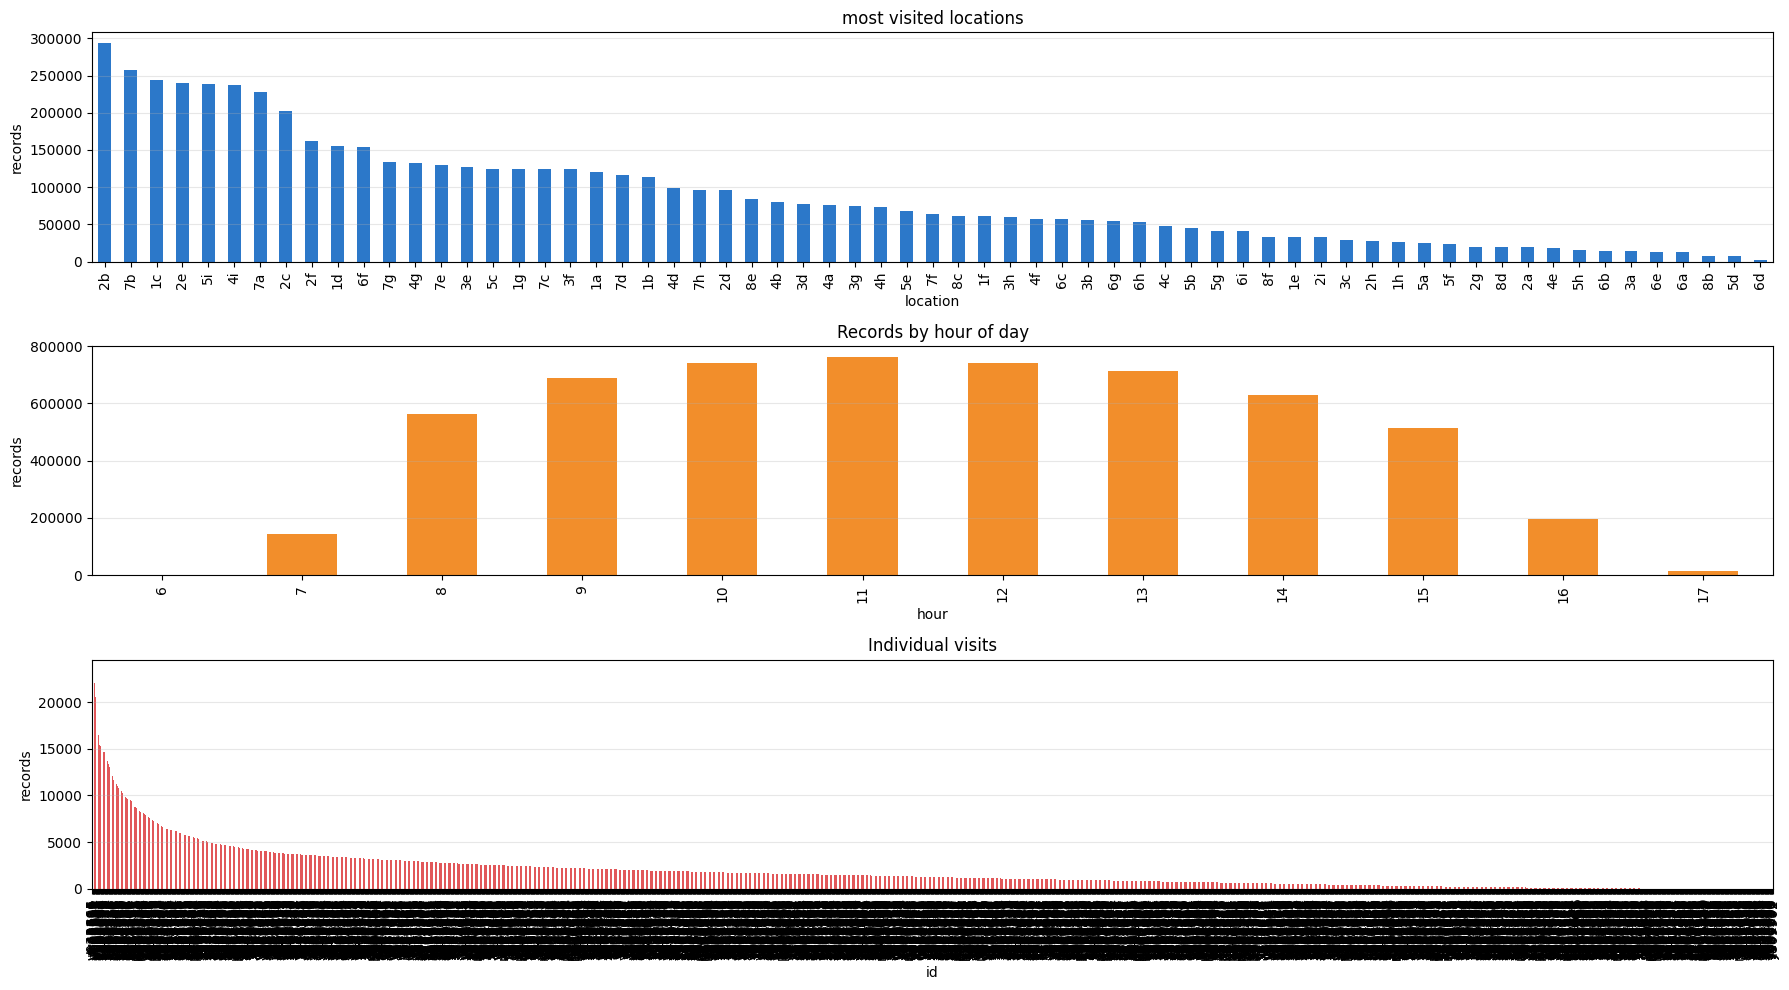

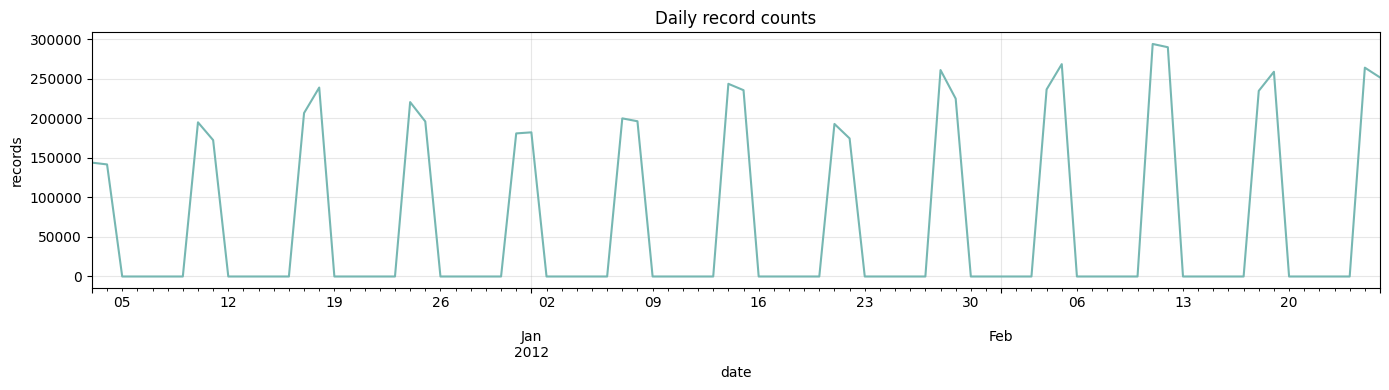

In [8]:

# Aggregations
loc_counts = df['location'].value_counts()#.head(20)
id_counts = df['id'].value_counts()#.head(50)
hours = df['time_dt'].dropna().dt.hour.value_counts().sort_index()
daily = (
    df.dropna(subset=['time_dt'])
    .groupby(pd.Grouper(key='time_dt', freq='D'))
    .size()
)

# 2x2 summary grid
fig, axes = plt.subplots(3, 1, figsize=(18, 10))

loc_counts.plot(kind='bar', ax=axes[0], color="#2c78c9", title='most visited locations')
axes[0].set_xlabel('location')
axes[0].set_ylabel('records')
axes[0].grid(alpha=0.3, axis='y')

# ant_counts.plot(kind='bar', ax=axes[0, 1], color='#59a14f', title='Antenna number distribution')
# axes[0, 1].set_xlabel('antenna')
# axes[0, 1].set_ylabel('records')
# axes[0, 1].grid(alpha=0.3, axis='y')

hours.plot(kind='bar', ax=axes[1], color='#f28e2b', title='Records by hour of day')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('records')
axes[1].grid(alpha=0.3, axis='y')

id_counts.plot(kind='bar', ax=axes[2], color='#e15759', title='Individual visits')
axes[2].set_xlabel('id')
axes[2].set_ylabel('records')
axes[2].grid(alpha=0.3, axis='y')
# for tick in axes[1, 1].get_xticklabels():
#     tick.set_rotation(90)

plt.tight_layout()

# Daily time series
plt.figure(figsize=(14, 4))
daily.plot(kind='line', color='#76b7b2', title='Daily record counts')
plt.xlabel('date')
plt.ylabel('records')
plt.grid(alpha=0.3)
plt.tight_layout()

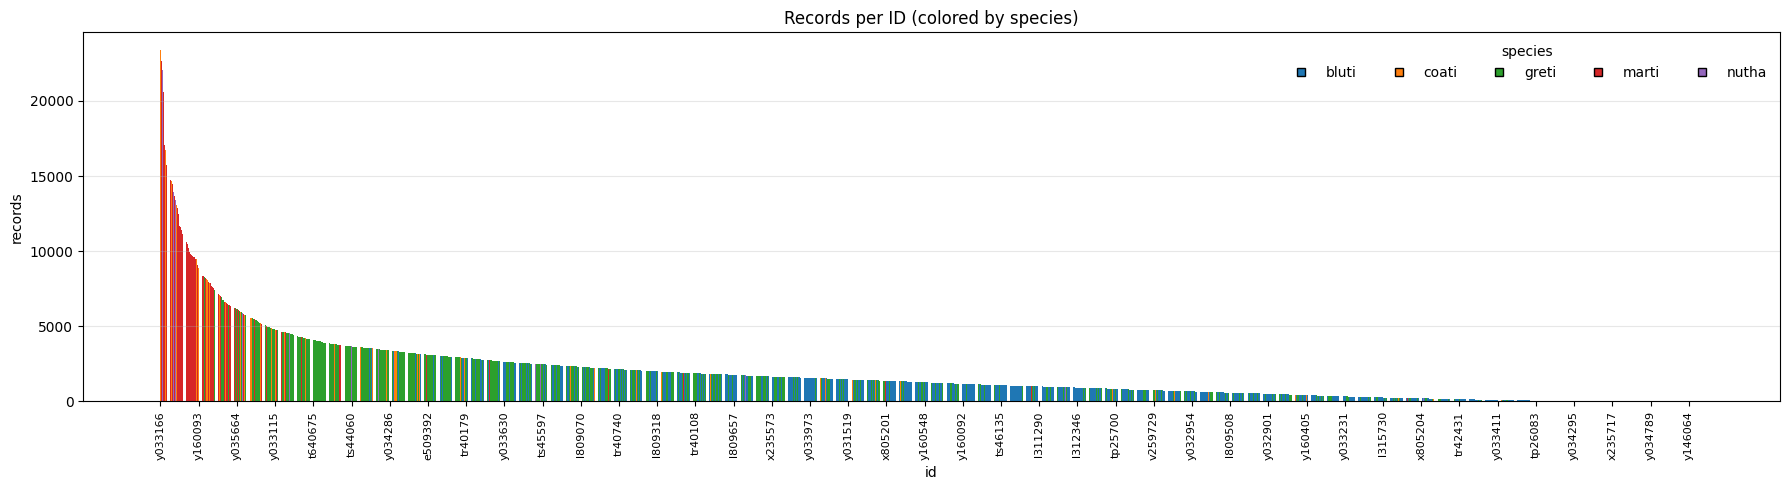

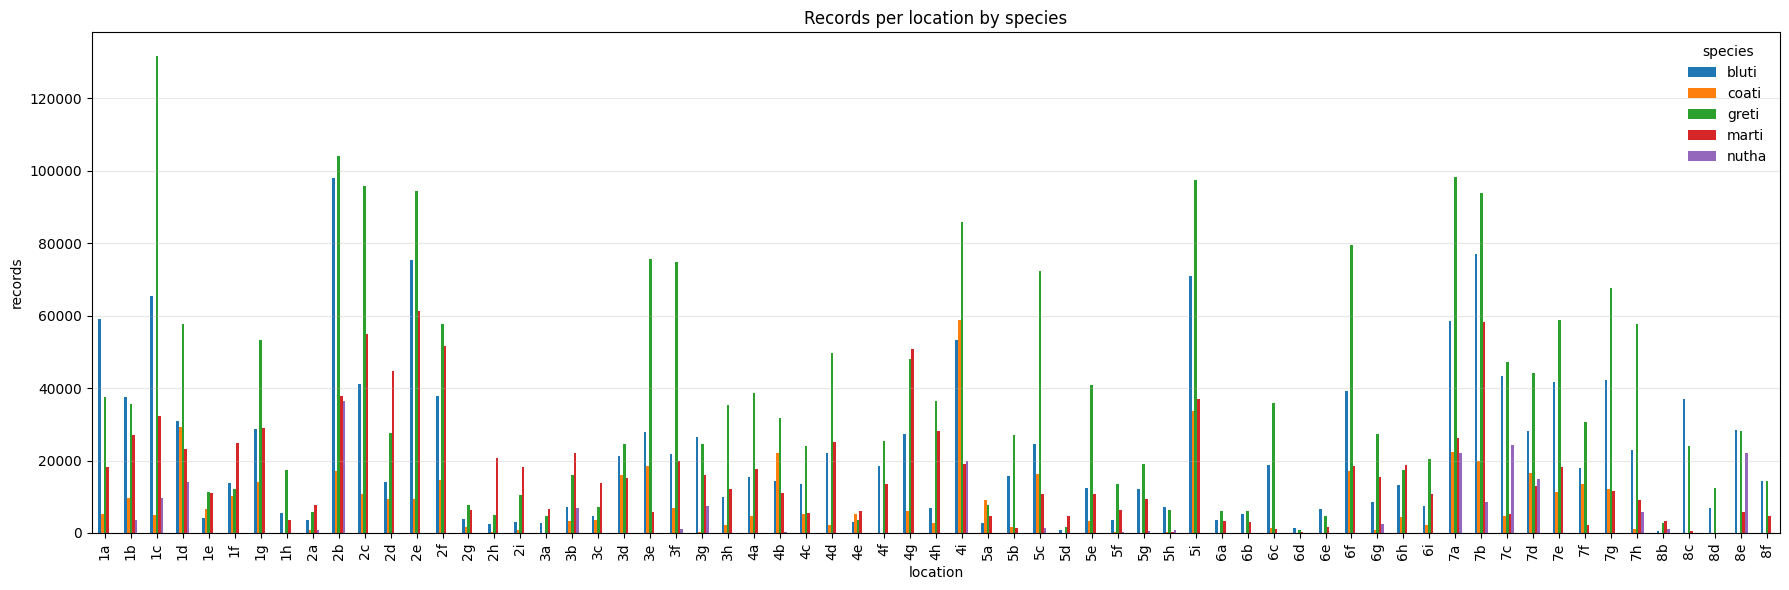

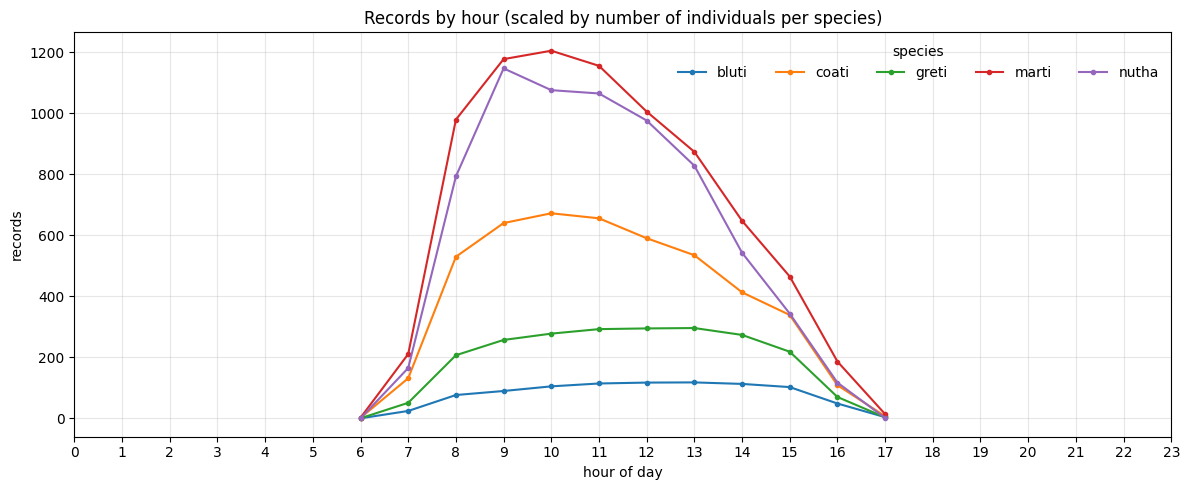

In [13]:
# Ensure species is attached to df
if 'species' not in df.columns:
    df = df.merge(df_ids[['id', 'species']], on='id', how='left')

# Consistent colors per species
species_order = sorted(df['species'].dropna().unique())
cmap = plt.get_cmap('tab10')
species_color = {sp: cmap(i % 10) for i, sp in enumerate(species_order)}

# 1) Records per ID, colored by species
id_counts_df = (
    id_counts.rename('records')
    .reset_index()
    .merge(df_ids[['id', 'species']], on='id', how='left')
)
fig1, ax1 = plt.subplots(figsize=(18, 5))
bar_colors = id_counts_df['species'].map(species_color).fillna('#cccccc')
ax1.bar(id_counts_df['id'], id_counts_df['records'], color=bar_colors, edgecolor='none')
ax1.set_title('Records per ID (colored by species)')
ax1.set_xlabel('id')
ax1.set_ylabel('records')
ax1.grid(alpha=0.3, axis='y')
# Thin x tick labels
if len(id_counts_df) > 40:
    step = max(1, len(id_counts_df) // 40)
    ax1.set_xticks(np.arange(0, len(id_counts_df), step))
    ax1.set_xticklabels(id_counts_df['id'].iloc[::step], rotation=90, fontsize=8)
else:
    ax1.set_xticklabels(id_counts_df['id'], rotation=90, fontsize=8)
handles_spec = [
    plt.Line2D([0], [0], marker='s', linestyle='None',
               markerfacecolor=species_color.get(sp), color='none', label=sp)
    for sp in species_order
]
if handles_spec:
    ax1.legend(handles=handles_spec, title='species', frameon=False, ncol=len(handles_spec))
fig1.tight_layout()

# 2) Records per location with a series for each species
loc_spec = (
    df.groupby(['location', 'species'])
    .size()
    .unstack(fill_value=0)
    .loc[sorted(df['location'].unique())]
)
fig2, ax2 = plt.subplots(figsize=(18, 6))
loc_spec.plot(kind='bar', ax=ax2,
              color=[species_color.get(sp, '#999999') for sp in loc_spec.columns])
ax2.set_title('Records per location by species')
ax2.set_xlabel('location')
ax2.set_ylabel('records')
ax2.grid(alpha=0.3, axis='y')
ax2.legend(title='species', frameon=False)
ax2.tick_params(axis='x', rotation=90)
fig2.tight_layout()

# 3) Records by hour with a series for each species
hour_spec = (
    df.dropna(subset=['time_dt'])
    .assign(hour=df['time_dt'].dt.hour)
    .groupby(['hour', 'species']).size()
    .unstack(fill_value=0)
    .sort_index()
)
fig3, ax3 = plt.subplots(figsize=(12, 5))
for sp in hour_spec.columns:
    num_ids = df_ids[df_ids['species'] == sp]['id'].nunique()
    ax3.plot(hour_spec.index, hour_spec[sp]/num_ids, marker='o', ms=3,
             label=sp, color=species_color.get(sp, None))
ax3.set_title('Records by hour (scaled by number of individuals per species)')
ax3.set_xlabel('hour of day')
ax3.set_ylabel('records')
ax3.set_xticks(range(0, 24))
ax3.grid(alpha=0.3)
ax3.legend(title='species', frameon=False, ncol=len(hour_spec.columns))
fig3.tight_layout()


# counts = (
#     df.dropna(subset=['time_dt'])
#       .assign(day=df['time_dt'].dt.floor('D'),
#               hour=df['time_dt'].dt.hour)
#       .groupby(['species','day','hour']).size()
#       .reset_index(name='records')
# )
# hourly_mean = (
#     counts.groupby(['species','hour'])['records']
#           .mean()
#           .reset_index()
# )

# fig4, ax4 = plt.subplots(figsize=(14, 6))
# for sp in species_order:
#     spm = (hourly_mean[hourly_mean['species'] == sp]
#            .set_index('hour')
#            .reindex(range(24))['records'])
#     if spm.notna().any():
#         ax4.plot(spm.index, spm.values, marker='o', ms=3,
#                  label=sp, color=species_color.get(sp, None))
# ax4.set_title('mean records by hour (per species, averaged across days)')
# ax4.set_xlabel('hour of day')
# ax4.set_ylabel('mean records')
# ax4.set_xticks(range(0, 24))
# ax4.grid(alpha=0.3)
# ax4.legend(title='species', frameon=False, ncol=len(species_order))
# fig4.tight_layout()

  species        day  hour       id  records
0   bluti 2011-12-03     7  j745372        5
1   bluti 2011-12-03     7  l171405       12
2   bluti 2011-12-03     7  l171442        6
3   bluti 2011-12-03     7  l310276        4
4   bluti 2011-12-03     7  l310485        1
  species        day  hour  mean_records_over_inds
0   bluti 2011-12-03     7                6.000000
1   bluti 2011-12-03     8                9.198198
2   bluti 2011-12-03     9                9.904215
3   bluti 2011-12-03    10                9.800000
4   bluti 2011-12-03    11                9.073718


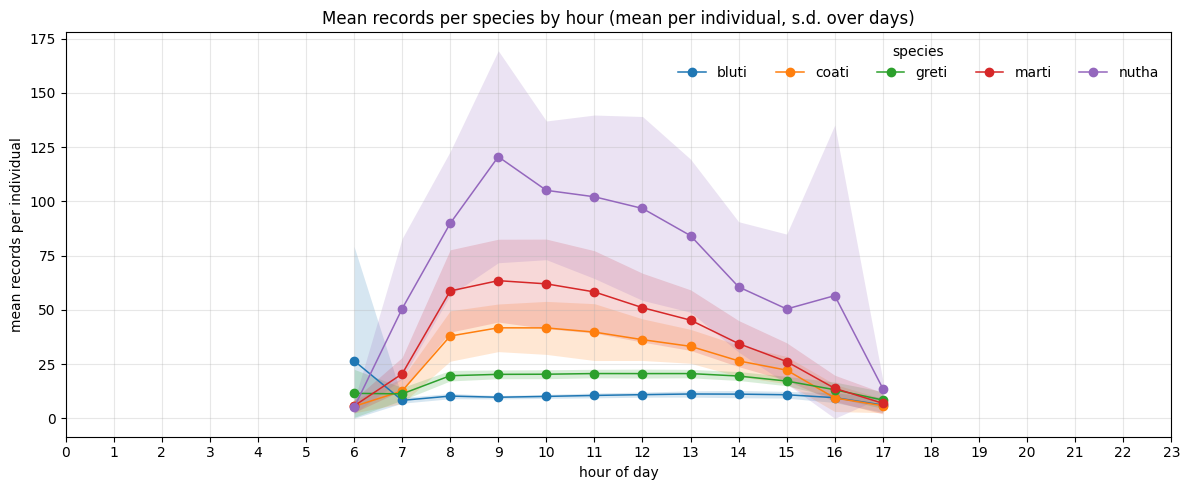

In [14]:
# Mean records per individual by hour (per species), averaged across days

# Per species-day-hour-individual: count records, gives the number of records per individual for each hour
records_ind = (
    df.dropna(subset=['time_dt'])
      .assign(day=df['time_dt'].dt.floor('D'),
              hour=df['time_dt'].dt.hour)
      .groupby(['species','day','hour','id'])
      .size()
      .reset_index(name='records')
)
print(records_ind.head())
# Per species-day-hour: average across individuals,
per_day_hour_mean = (
    records_ind.groupby(['species','day','hour'])['records']
               .mean()
               .reset_index(name='mean_records_over_inds')
)
print(per_day_hour_mean.head())
# Per species-hour: mean ± std across days of the per-species mean
hourly_per_ind_stats = (
    per_day_hour_mean.groupby(['species','hour'])['mean_records_over_inds']
                     .agg(['mean','std'])
                     .reset_index()
)

# Plot with ribbon
fig, ax = plt.subplots(figsize=(12, 5))
hours = np.arange(24)
for sp in species_order:
    sp_stats = (hourly_per_ind_stats[hourly_per_ind_stats['species'] == sp]
                .set_index('hour')
                .reindex(range(24)))
    if sp_stats['mean'].notna().any():
        ribbon(ax, hours,
               sp_stats['mean'],             # pass Series so clip(lower=0) works
               sp_stats['std'].fillna(0),
               label=sp, color=species_color.get(sp), floor_zero=True)

ax.set_xticks(hours)
ax.set_xlabel('hour of day')
ax.set_ylabel('mean records per individual')
ax.set_title('Mean records per species by hour (mean per individual, s.d. over days)')
ax.grid(alpha=0.3)
ax.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

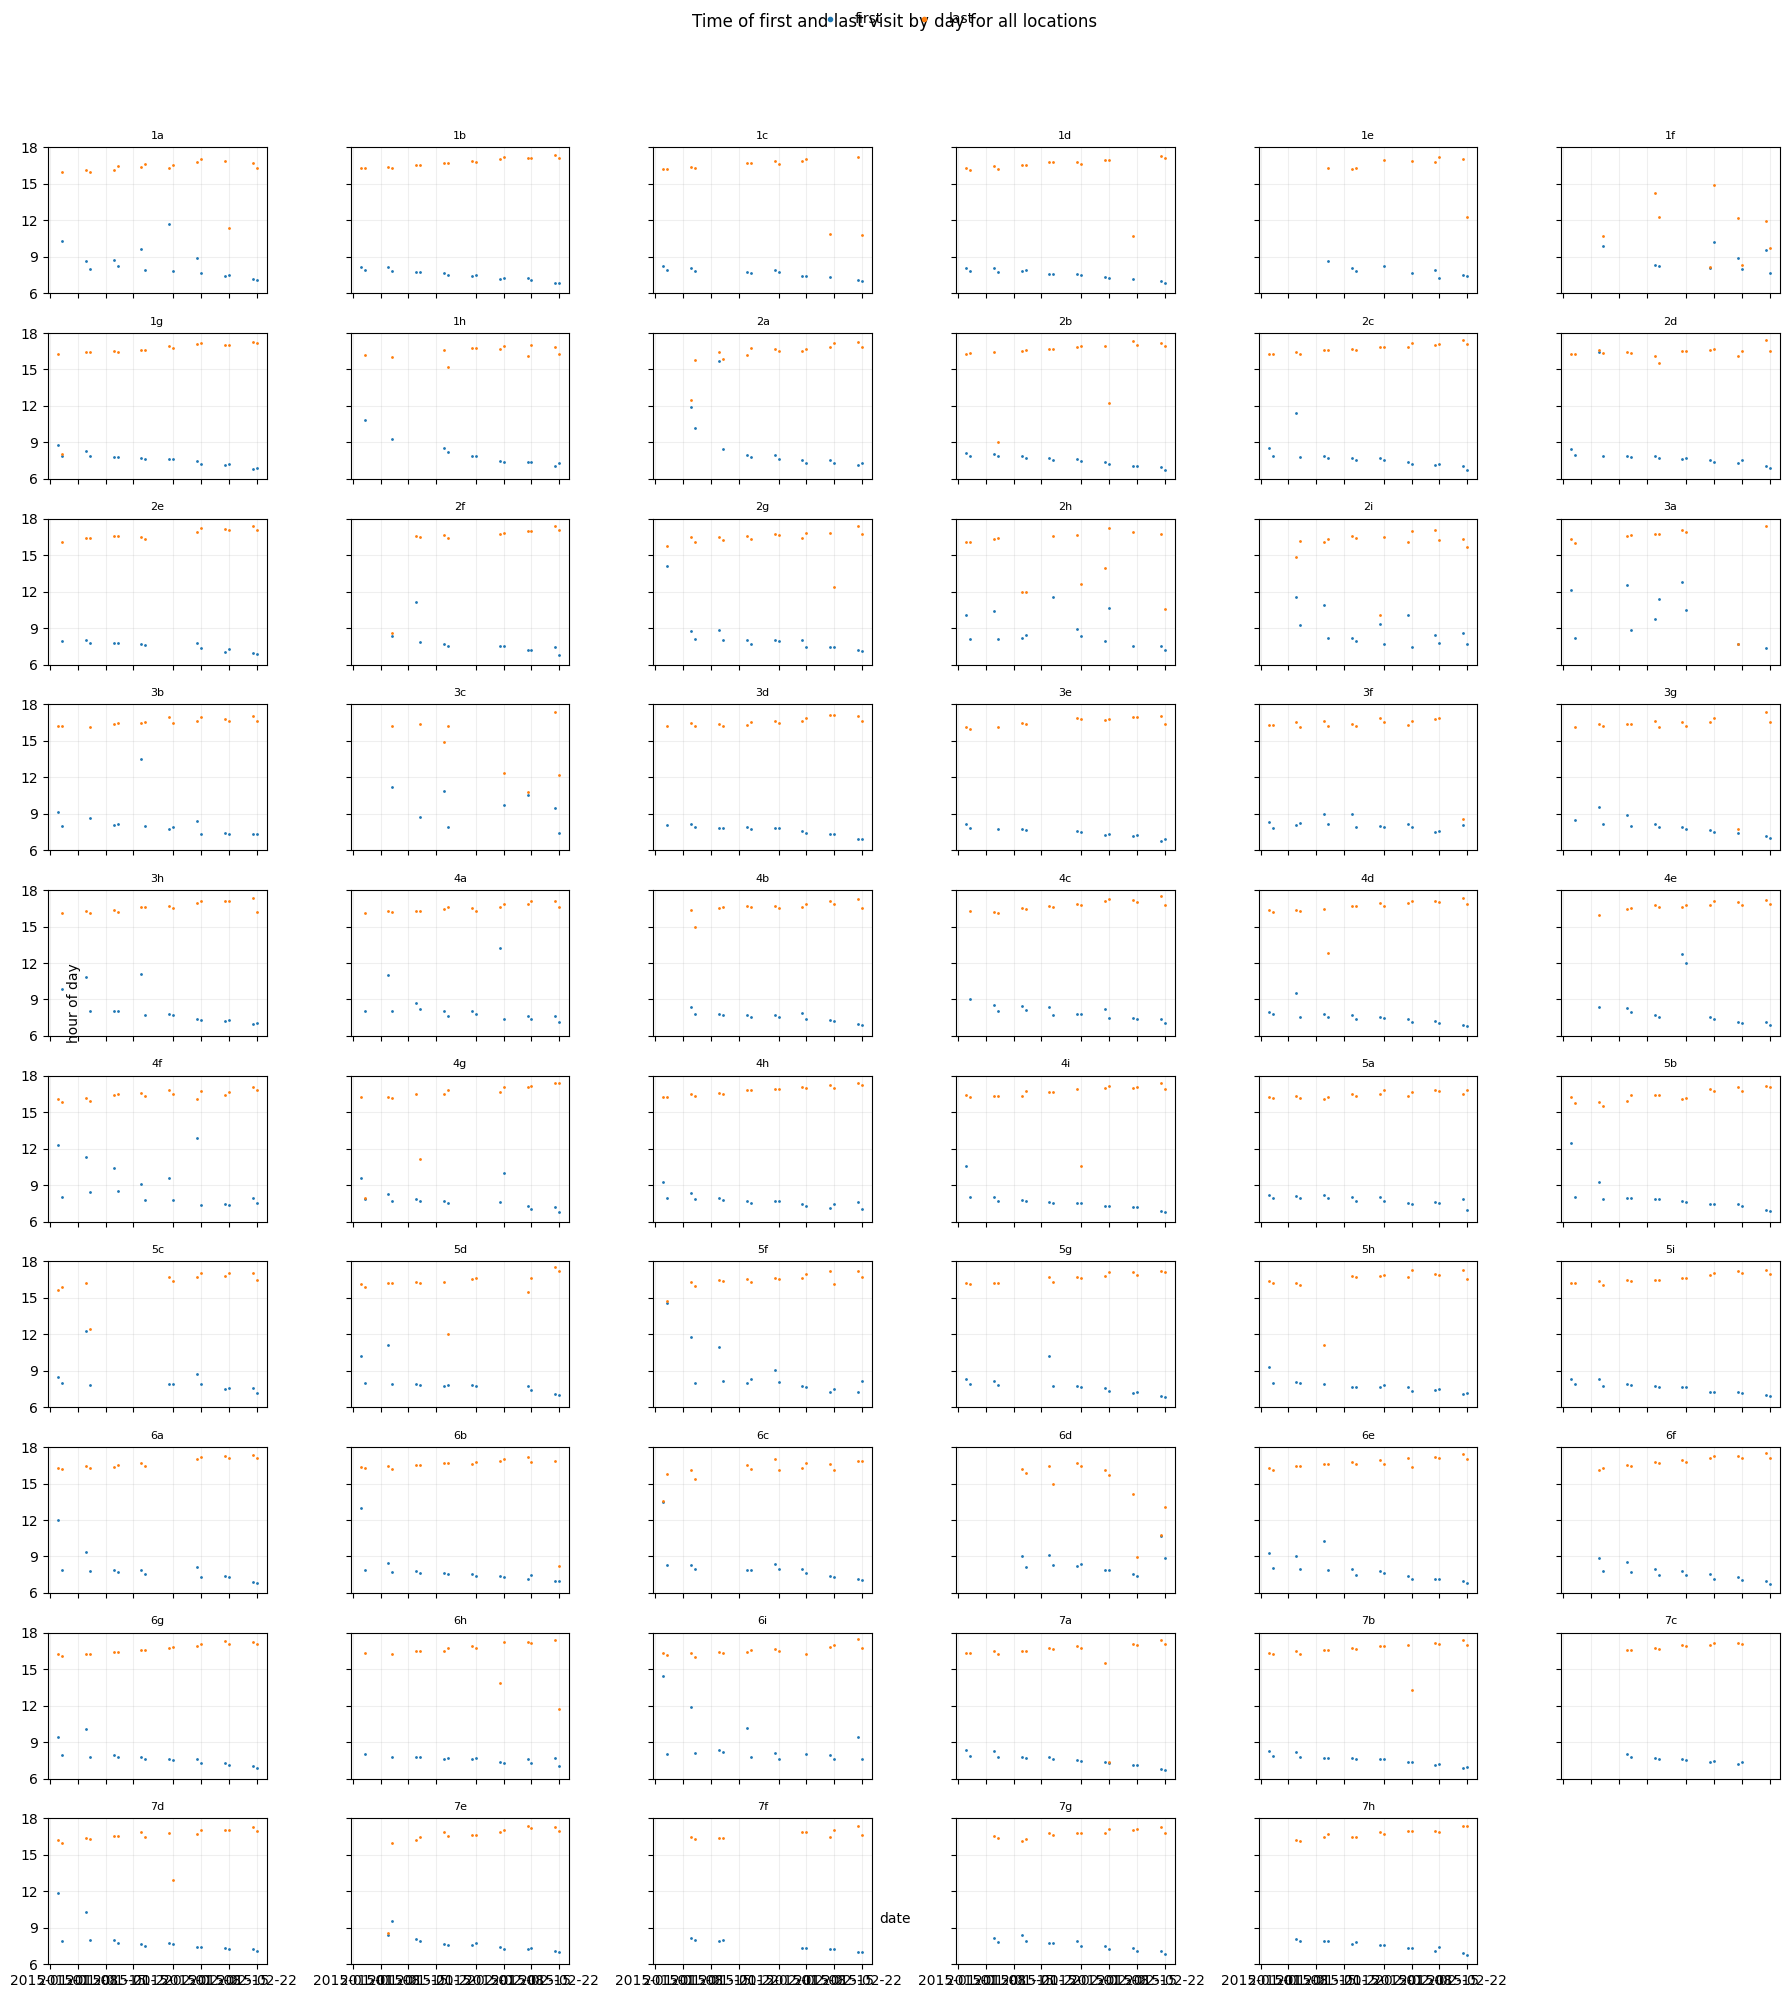

In [ ]:
# First/last visit time by day for each location

# Ensure a day column exists
if 'day' not in df.columns:
    df['day'] = df['time_dt'].dt.floor('D')

# Aggregate first and last visit times per location/day
loc_day_times = (
    df.dropna(subset=['time_dt'])
    .groupby(['location', 'day'])['time_dt']
    .agg(first_time='min', last_time='max')
    .reset_index()
)

# Convert to hour-of-day (float) for plotting on y-axis
for col in ('first_time', 'last_time'):
    loc_day_times[f'{col}_hour'] = (
        loc_day_times[col].dt.hour
        + loc_day_times[col].dt.minute / 60
        + loc_day_times[col].dt.second / 3600
    )

# Plot small multiples for all locations
locations = sorted(loc_day_times['location'].unique())
n = len(locations)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig_times, axes_times = plt.subplots(
    nrows, ncols, figsize=(ncols * 3, nrows * 2), sharex=True, sharey=True
)
axs = axes_times.ravel() if isinstance(axes_times, np.ndarray) else [axes_times]

for i, loc in enumerate(locations):
    ax = axs[i]
    sub = loc_day_times[loc_day_times['location'] == loc]
    ax.plot(sub['day'], sub['first_time_hour'], '.', ms=2, color='#1f77b4', label='first')
    ax.plot(sub['day'], sub['last_time_hour'], '.', ms=2, color='#ff7f0e', label='last')
    ax.set_title(loc, fontsize=8)
    ax.grid(alpha=0.2)
    ax.set_ylim(6, 18)
    ax.set_yticks([6,9, 12,15, 18])

# Hide any unused subplots
for j in range(len(locations), len(axs)):
    axs[j].axis('off')

# Shared labels and legend
fig_times.suptitle('Time of first and last visit by day for all locations', y=0.995)
fig_times.text(0.5, 0.04, 'date', ha='center')
fig_times.text(0.04, 0.5, 'hour of day', va='center', rotation='vertical')

handles = [
    plt.Line2D([0], [0], marker='.', linestyle='None', color='#1f77b4', label='first'),
    plt.Line2D([0], [0], marker='.', linestyle='None', color='#ff7f0e', label='last'),
]
fig_times.legend(handles=handles, loc='upper center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0, 1, 0.96))

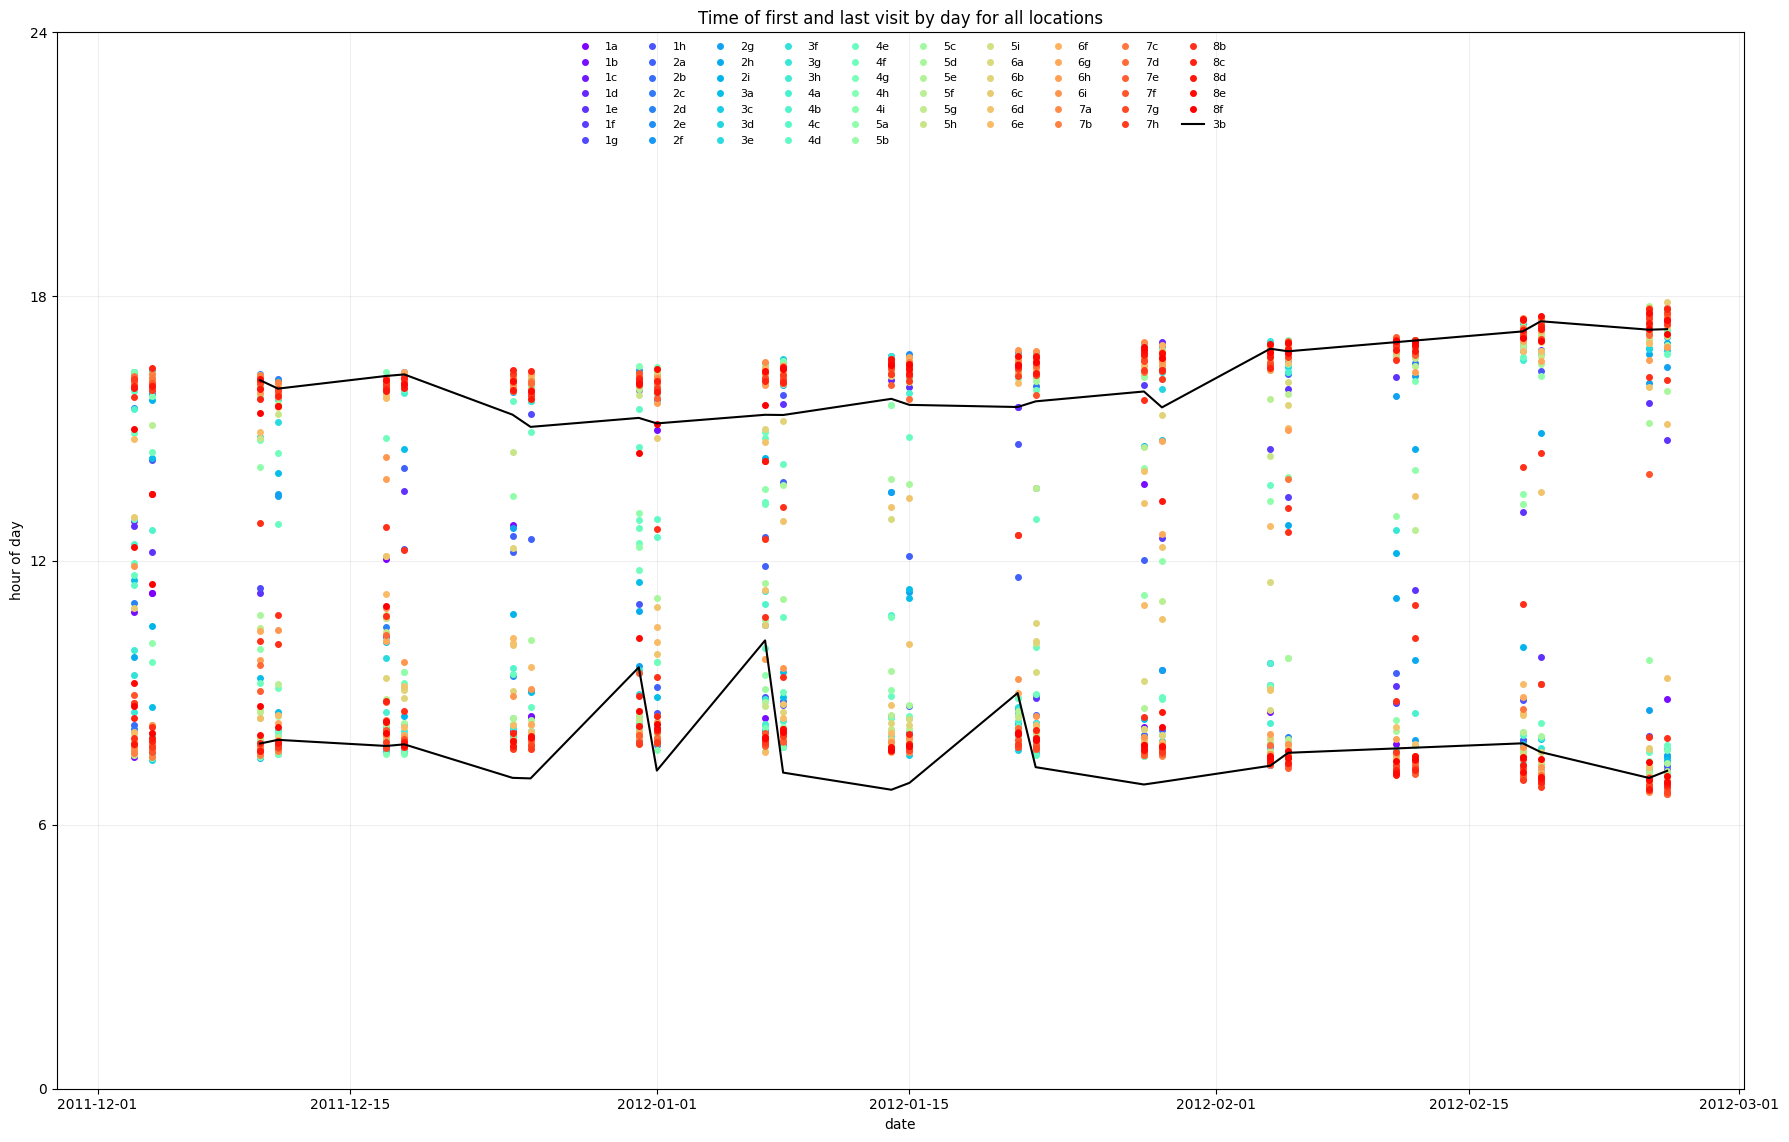

In [16]:
# First/last visit time by day for each location

# Ensure a day column exists
if 'day' not in df.columns:
    df['day'] = df['time_dt'].dt.floor('D')

# Aggregate first and last visit times per location/day
loc_day_times = (
    df.dropna(subset=['time_dt'])
    .groupby(['location', 'day'])['time_dt']
    .agg(first_time='min', last_time='max')
    .reset_index()
)

# Convert to hour-of-day (float) for plotting on y-axis
for col in ('first_time', 'last_time'):
    loc_day_times[f'{col}_hour'] = (
        loc_day_times[col].dt.hour
        + loc_day_times[col].dt.minute / 60
        + loc_day_times[col].dt.second / 3600
    )

# Plot small plots for all locations
locations = sorted(loc_day_times['location'].unique())
n = len(locations)
ncols = 6
nrows = int(np.ceil(n / ncols))


plt.figure(figsize=(18, 12))
colors = cm.rainbow (np.linspace(0, 1, len(locations)))
for i, loc in enumerate(locations):
    sub = loc_day_times[loc_day_times['location'] == loc]
    if loc == '3b':
        pass
    else:
        plt.plot(sub['day'], sub['first_time_hour'], '.', ms=8, label=loc, color = colors[i])
        plt.plot(sub['day'], sub['last_time_hour'], '.', ms=8, color = colors[i])

#plot clear outlier on top in black
loc = '3b'
sub = loc_day_times[loc_day_times['location'] == loc]
plt.plot(sub['day'], sub['first_time_hour'] , ms=8, label=loc, color = 'black')
plt.plot(sub['day'], sub['last_time_hour'], ms=8, color = 'black')

plt.grid(alpha=0.2)
plt.ylim(0, 24)
plt.yticks([0, 6, 12, 18, 24])

plt.title('Time of first and last visit by day for all locations')
plt.xlabel('date')
plt.ylabel('hour of day')
plt.legend(loc='upper center', ncol=10, frameon=False, fontsize=8)
# # Shared labels and legend
# fig_times.suptitle('Time of first and last visit by day for all locations', y=0.995)
# fig_times.text(0.5, 0.04, 'date', ha='center')
# fig_times.text(0.04, 0.5, 'hour of day', va='center', rotation='vertical')

# handles = [
#     plt.Line2D([0], [0], marker='.', linestyle='None', color='#1f77b4', label='first'),
#     plt.Line2D([0], [0], marker='.', linestyle='None', color='#ff7f0e', label='last'),
# ]
# fig_times.legend(handles=handles, loc='upper center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0, 1, 0.96))

# convert records to visits

In [15]:
print(df.head())
df.info()

        id location                 time  antenna_number species  \
0  y033624       1b  2011-12-03 07:31:40               2   marti   
1  y033624       1b  2011-12-03 07:31:41               2   marti   
2  y033624       1b  2011-12-03 07:31:42               2   marti   
3  y033624       1b  2011-12-03 07:31:43               2   marti   
4  y033624       1b  2011-12-03 07:31:44               2   marti   

              time_dt  
0 2011-12-03 07:31:40  
1 2011-12-03 07:31:41  
2 2011-12-03 07:31:42  
3 2011-12-03 07:31:43  
4 2011-12-03 07:31:44  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5704247 entries, 0 to 5704246
Data columns (total 6 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              object        
 1   location        object        
 2   time            object        
 3   antenna_number  int64         
 4   species         object        
 5   time_dt         datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)


In [67]:
df_process = df.dropna(subset=['time_dt']).sort_values(['id', 'time_dt']).copy()
df_process=df_process.reset_index(drop=True)
df_process = df_process[['id', 'location', 'species', 'time_dt']]
df_process = df_process.sort_values(['id', 'time_dt'])


In [68]:
df_process.info()
df_process.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5704247 entries, 0 to 5704246
Data columns (total 4 columns):
 #   Column    Dtype         
---  ------    -----         
 0   id        object        
 1   location  object        
 2   species   object        
 3   time_dt   datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 174.1+ MB


,id,location,species,time_dt
0,c695905,1c,bluti,2011-12-03 08:34:37
1,c695905,1c,bluti,2011-12-03 08:34:38
2,c695905,1c,bluti,2011-12-03 08:35:11
3,c695905,1c,bluti,2011-12-03 08:35:12
4,c695905,1c,bluti,2011-12-03 08:38:14
5,c695905,1c,bluti,2011-12-03 08:38:15
6,c695905,1c,bluti,2011-12-03 08:39:18
7,c695905,1c,bluti,2011-12-03 08:39:19
8,c695905,1c,bluti,2011-12-03 09:04:49
9,c695905,1c,bluti,2011-12-03 09:04:50


In [69]:
# calculate time difference between records for each bird
# if time difference crosses the night into the next day, remove as not a journey, just overnight roost
# if time difference larger than 3 minutes or location changes, we consider this a departure and then a new arrival
# remove all records which are not arrivals or departures



df_process['time_diff'] = df_process.groupby('id')['time_dt'].diff().dt.total_seconds()

# compare location within the same id
loc_changed = df_process['location'].ne(df_process.groupby('id')['location'].shift())

# new visit if >3 minutes OR location changed (even within 10 minutes)
df_process['is_new_visit'] = (df_process['time_diff'] > 600) | loc_changed.fillna(False)
# arrivial is a new visit or first record for id
df_process['is_arrival'] = df_process['is_new_visit']# | (df_process.groupby('id').cumcount() == 0)

# do the next-visit shift within each id to avoid cross-id leakage
df_process['is_departure'] = (
    df_process.groupby('id')['is_new_visit'].shift(-1, fill_value=True)
    | (df_process.groupby('id').cumcount(ascending=False) == 0)
)


# # df_process['is_new_visit'] = (df_process['time_diff'] > 180)  | (df_process['location'] != df_process['location'].shift())      
# df_process['is_new_visit'] = (df_process['time_diff'] > 180)       # for some reason line before gives really weird results

# df_process['is_arrival'] = df_process['is_new_visit'] | (df_process.groupby('id').cumcount() == 0) # new visit or first record for id
# df_process['is_departure'] = df_process['is_new_visit'].shift(-1, fill_value=True) | (df_process.groupby('id').cumcount(ascending=False) == 0) # departure if next is new visit or last record for id



df_ariv_depart = df_process[df_process['is_arrival'] | df_process['is_departure']].copy() # only keep arrivals and departures
df_ariv_depart = df_ariv_depart.drop(columns=['time_diff', 'is_new_visit', 'is_arrival', 'is_departure'])
df_ariv_depart = df_ariv_depart.reset_index(drop=True)


In [40]:
df_process.head(50)

,id,location,species,time_dt,time_diff,is_new_visit,is_arrival,is_departure
0,c695905,1c,bluti,2011-12-03 08:34:37,NaN,True,True,False
1,c695905,1c,bluti,2011-12-03 08:34:38,1.0,False,False,False
2,c695905,1c,bluti,2011-12-03 08:35:11,33.0,False,False,False
3,c695905,1c,bluti,2011-12-03 08:35:12,1.0,False,False,False
4,c695905,1c,bluti,2011-12-03 08:38:14,182.0,False,False,False
5,c695905,1c,bluti,2011-12-03 08:38:15,1.0,False,False,False
6,c695905,1c,bluti,2011-12-03 08:39:18,63.0,False,False,False
7,c695905,1c,bluti,2011-12-03 08:39:19,1.0,False,False,True
8,c695905,1c,bluti,2011-12-03 09:04:49,1530.0,True,True,False
9,c695905,1c,bluti,2011-12-03 09:04:50,1.0,False,False,True


In [70]:
print(df_ariv_depart.info())
print(f'preprocess - {len(df_process)} records, arrivals/departures - {len(df_ariv_depart)} records. reduction of {len(df_process)-len(df_ariv_depart)} records')
df_ariv_depart.head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973054 entries, 0 to 973053
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        973054 non-null  object        
 1   location  973054 non-null  object        
 2   species   973054 non-null  object        
 3   time_dt   973054 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 29.7+ MB
None
preprocess - 5704247 records, arrivals/departures - 973054 records. reduction of 4731193 records


,id,location,species,time_dt
0,c695905,1c,bluti,2011-12-03 08:34:37
1,c695905,1c,bluti,2011-12-03 08:39:19
2,c695905,1c,bluti,2011-12-03 09:04:49
3,c695905,1c,bluti,2011-12-03 09:04:50
4,c695905,1d,bluti,2011-12-03 09:48:51
5,c695905,1d,bluti,2011-12-03 09:50:43
6,c695905,1d,bluti,2011-12-03 10:26:05
7,c695905,1d,bluti,2011-12-03 10:28:08
8,c695905,1d,bluti,2011-12-03 10:52:53
9,c695905,1d,bluti,2011-12-03 10:55:02


In [85]:

df_process['time_diff'] = df_process.groupby('id')['time_dt'].diff().dt.total_seconds()

# compare location within the same id
loc_changed = df_process['location'].ne(df_process.groupby('id')['location'].shift())

# new visit if location changed ONLY
df_process['is_new_visit'] = loc_changed.fillna(False)
# arrivial is a new visit or first record for id
df_process['is_arrival'] = df_process['is_new_visit'] | (df_process.groupby('id').cumcount() == 0)

# do the next-visit shift within each id to avoid cross-id leakage
df_process['is_departure'] = (
    df_process.groupby('id')['is_new_visit'].shift(-1, fill_value=True)
    | (df_process.groupby('id').cumcount(ascending=False) == 0)
)

df_new_loc = df_process[df_process['is_arrival'] | df_process['is_departure']].copy() # only keep arrivals and departures
df_new_loc = df_new_loc.drop(columns=['time_diff', 'is_new_visit', 'is_arrival', 'is_departure'])
# df_new_loc = df_new_loc.reset_index(drop=True)

In [86]:
df_new_loc.head(73)

,id,location,species,time_dt
0,c695905,1c,bluti,2011-12-03 08:34:37
9,c695905,1c,bluti,2011-12-03 09:04:50
10,c695905,1d,bluti,2011-12-03 09:48:51
97,c695905,1d,bluti,2011-12-04 10:57:23
98,c695905,1c,bluti,2011-12-04 11:22:51
...,...,...,...,...
1610,c695905,1c,bluti,2012-02-26 16:26:27
1611,c695958,2b,bluti,2011-12-31 09:54:20
2855,c695958,2b,bluti,2012-02-26 16:51:47
2856,e018488,2h,greti,2011-12-03 10:10:12


# Speeds

In [79]:
bird_id = id_counts_df['id'][0] # get the most frequent bird id
print(bird_id)

y033166


In [ ]:
# Lookup table for distances between locations
D = pd.DataFrame(
    cdist(df_locations[['x','y']], df_locations[['x','y']], metric='euclidean'),
    index=df_locations['Name'], columns=df_locations['Name']
)
# example lookup: d_ij = D.loc['1A','1E']  # metres, should be 761.8758862176879 for 1A to 1E
assert(D.loc['1A','1E'] == 761.8758862176879)  # metres, should be 761.8758862176879 for 1A to 1E


In [36]:
# distance to the next row's location (per id)
df_ariv_depart['next_location'] = df_ariv_depart.groupby('id')['location'].shift(-1)
df_ariv_depart['next_time'] = df_ariv_depart.groupby('id')['time_dt'].shift(-1)
df_ariv_depart['dt'] = (df_ariv_depart['next_time'] - df_ariv_depart['time_dt']).dt.total_seconds()
# drop rows where next_location is NaN (last record per id)
df_ariv_depart = df_ariv_depart.dropna().reset_index(drop=True)
# distance between current and next location
df_ariv_depart['distance'] = df_ariv_depart.apply(
    lambda row: D.loc[row['location'].upper(), row['next_location'].upper()], axis=1
)
df_ariv_depart['speed_m_s'] = df_ariv_depart['distance'] / df_ariv_depart['dt']

In [37]:
df_visit = df_ariv_depart.sort_values(['id','time_dt'])
df_visit.head(30)


,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s
0,c695905,1c,bluti,2011-12-03 08:34:37,1c,2011-12-03 08:35:12,35.0,0.000000,0.000000
1,c695905,1c,bluti,2011-12-03 08:35:12,1c,2011-12-03 08:38:14,182.0,0.000000,0.000000
2,c695905,1c,bluti,2011-12-03 08:38:14,1c,2011-12-03 08:39:19,65.0,0.000000,0.000000
3,c695905,1c,bluti,2011-12-03 08:39:19,1c,2011-12-03 09:04:49,1530.0,0.000000,0.000000
4,c695905,1c,bluti,2011-12-03 09:04:49,1c,2011-12-03 09:04:50,1.0,0.000000,0.000000
5,c695905,1c,bluti,2011-12-03 09:04:50,1d,2011-12-03 09:48:51,2641.0,275.870519,0.104457
6,c695905,1d,bluti,2011-12-03 09:48:51,1d,2011-12-03 09:50:43,112.0,0.000000,0.000000
7,c695905,1d,bluti,2011-12-03 09:50:43,1d,2011-12-03 10:26:05,2122.0,0.000000,0.000000
8,c695905,1d,bluti,2011-12-03 10:26:05,1d,2011-12-03 10:28:08,123.0,0.000000,0.000000
9,c695905,1d,bluti,2011-12-03 10:28:08,1d,2011-12-03 10:52:53,1485.0,0.000000,0.000000


In [87]:
# for df_new_loc only
# distance to the next row's location (per id)
df_new_loc['next_location'] = df_new_loc.groupby('id')['location'].shift(-1)
df_new_loc['next_time'] = df_new_loc.groupby('id')['time_dt'].shift(-1)
df_new_loc['dt'] = (df_new_loc['next_time'] - df_new_loc['time_dt']).dt.total_seconds()
# drop rows where next_location is NaN (last record per id)
df_new_loc = df_new_loc.dropna().reset_index(drop=True)
# distance between current and next location
df_new_loc['distance'] = df_new_loc.apply(
    lambda row: D.loc[row['location'].upper(), row['next_location'].upper()], axis=1
)
df_new_loc['speed_m_s'] = df_new_loc['distance'] / df_new_loc['dt']



In [88]:
# remove speeds when the next record was from the following or more day
df_new_loc['same_day'] = df_new_loc['time_dt'].dt.date == df_new_loc['next_time'].dt.date
df_new_loc['speed_m_s'] = np.where(
    df_new_loc['same_day'] | df_new_loc['next_time'].isna(),
    df_new_loc['speed_m_s'],
    0.0
)


In [89]:
df_visit = df_new_loc.sort_values(['id','time_dt'])
df_visit.head(30)

,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s,same_day
0,c695905,1c,bluti,2011-12-03 08:34:37,1c,2011-12-03 09:04:50,1813.0,0.000000,0.000000,True
1,c695905,1c,bluti,2011-12-03 09:04:50,1d,2011-12-03 09:48:51,2641.0,275.870519,0.104457,True
2,c695905,1d,bluti,2011-12-03 09:48:51,1d,2011-12-04 10:57:23,90512.0,0.000000,0.000000,False
3,c695905,1d,bluti,2011-12-04 10:57:23,1c,2011-12-04 11:22:51,1528.0,275.870519,0.180544,True
4,c695905,1c,bluti,2011-12-04 11:22:51,1c,2011-12-10 11:00:26,517055.0,0.000000,0.000000,False
5,c695905,1c,bluti,2011-12-10 11:00:26,1d,2011-12-10 11:15:12,886.0,275.870519,0.311366,True
6,c695905,1d,bluti,2011-12-10 11:15:12,1d,2011-12-11 10:57:17,85325.0,0.000000,0.000000,False
7,c695905,1d,bluti,2011-12-11 10:57:17,1c,2011-12-11 11:24:15,1618.0,275.870519,0.170501,True
8,c695905,1c,bluti,2011-12-11 11:24:15,1c,2011-12-11 15:39:59,15344.0,0.000000,0.000000,True
9,c695905,1c,bluti,2011-12-11 15:39:59,1d,2011-12-17 09:13:08,495189.0,275.870519,0.000000,False


In [90]:
df_bird_speed = df_visit[df_visit['id'] == bird_id].copy()
df_bird_speed.head(60)
df_bird_speed.info()


<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 42230 to 42252
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             23 non-null     object        
 1   location       23 non-null     object        
 2   species        23 non-null     object        
 3   time_dt        23 non-null     datetime64[ns]
 4   next_location  23 non-null     object        
 5   next_time      23 non-null     datetime64[ns]
 6   dt             23 non-null     float64       
 7   distance       23 non-null     float64       
 8   speed_m_s      23 non-null     float64       
 9   same_day       23 non-null     bool          
dtypes: bool(1), datetime64[ns](2), float64(3), object(4)
memory usage: 1.8+ KB


# speed and dist plots

Text(0.5, 1.0, 'log(speed m/s) over time for y033166')

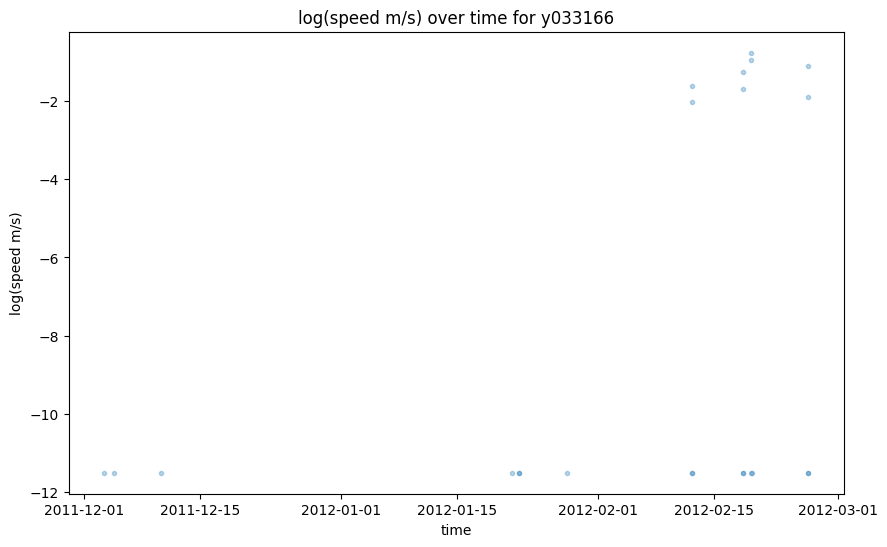

In [91]:
fig, ax = plt.subplots(figsize=(10, 6))

plt.plot(df_bird_speed['time_dt'], np.log(df_bird_speed['speed_m_s']+0.00001), '.', alpha=0.3)
plt.xlabel('time')
plt.ylabel('log(speed m/s)')
plt.title(f'log(speed m/s) over time for {bird_id}')

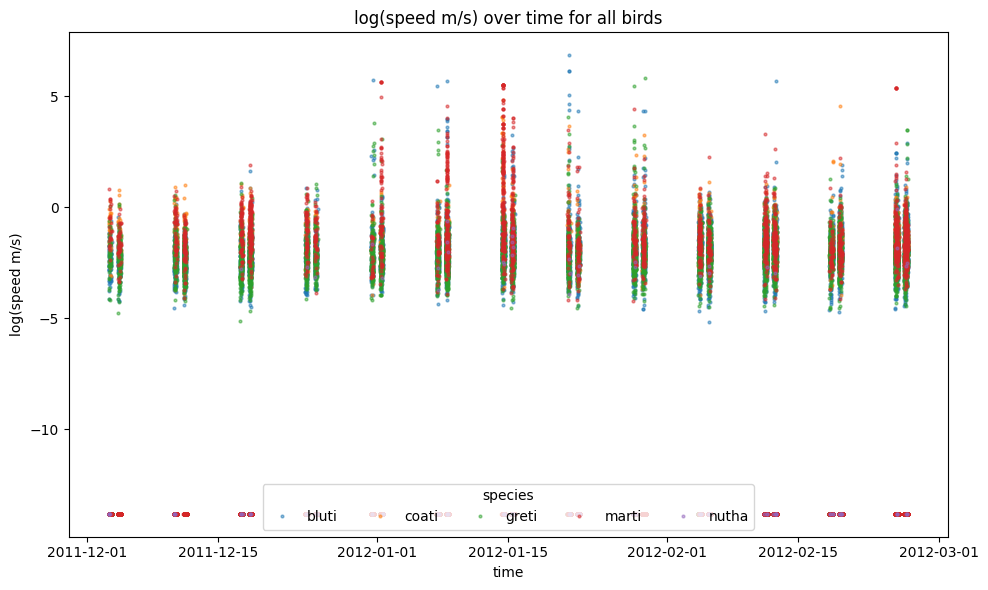

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

for sp in species_order:
    sub = df_visit[df_visit['species'] == sp]
    if len(sub) == 0:
        continue
    plt.plot(sub['time_dt'], np.log(sub['speed_m_s'] + 1e-6), '.', ms=4,
             alpha=0.5, color=species_color.get(sp), label=sp)

plt.xlabel('time')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over time for all birds')
plt.legend(title='species', ncol=len(species_order), loc ='lower center')
plt.tight_layout()

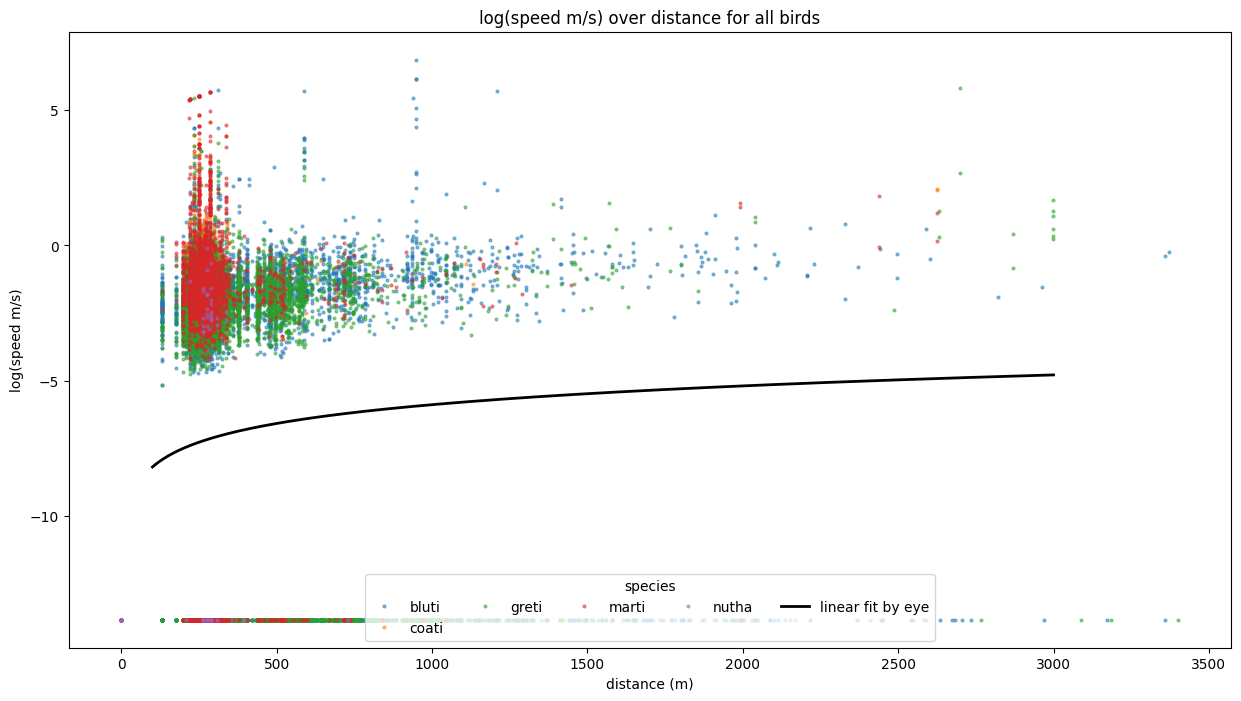

In [33]:
fig, ax = plt.subplots(figsize=(15, 8))
for sp in species_order:
    sub = df_visit[df_visit['species'] == sp]
    if len(sub) == 0:
        continue
    plt.plot(sub['distance'], np.log(sub['speed_m_s'] + 1e-6), '.', ms=4,
             alpha=0.5, color=species_color.get(sp), label=sp)
# fit by eye
x = np.linspace(100,3000,1000)
y = 0.0000028*x-0.000000051
plt.plot(x, np.log(y + 1e-6), 'k-', lw=2, label='linear fit by eye')


# plt.plot(df_visit['distance'], np.log(df_visit['speed_m_s']+0.0000001), '.', alpha=0.3)
plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance for all birds')
plt.legend(title='species', ncol=len(species_order), loc = 'lower center')



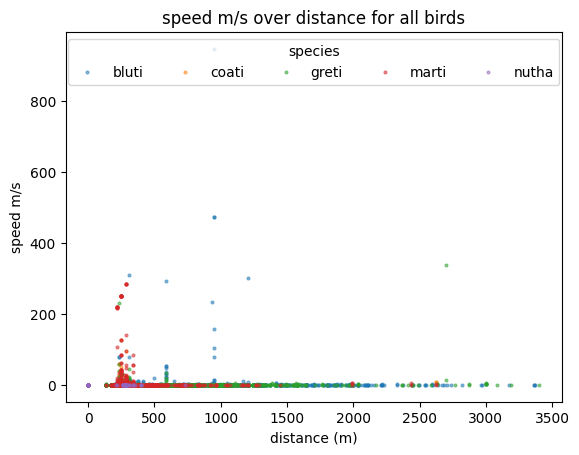

In [34]:
for sp in species_order:
    sub = df_visit[df_visit['species'] == sp]
    if len(sub) == 0:
        continue
    plt.plot(sub['distance'], sub['speed_m_s'] , '.', ms=4,
             alpha=0.5, color=species_color.get(sp), label=sp)

# plt.plot(df_visit['distance'], np.log(df_visit['speed_m_s']+0.0000001), '.', alpha=0.3)
plt.xlabel('distance (m)')
plt.ylabel('speed m/s')
plt.title('speed m/s over distance for all birds')
plt.legend(title='species', ncol=len(species_order), loc = 'upper center')

In [35]:
# remove zero speeds (stay in same location)
df_visit_no_zero = df_visit[df_visit['speed_m_s']>0].copy()

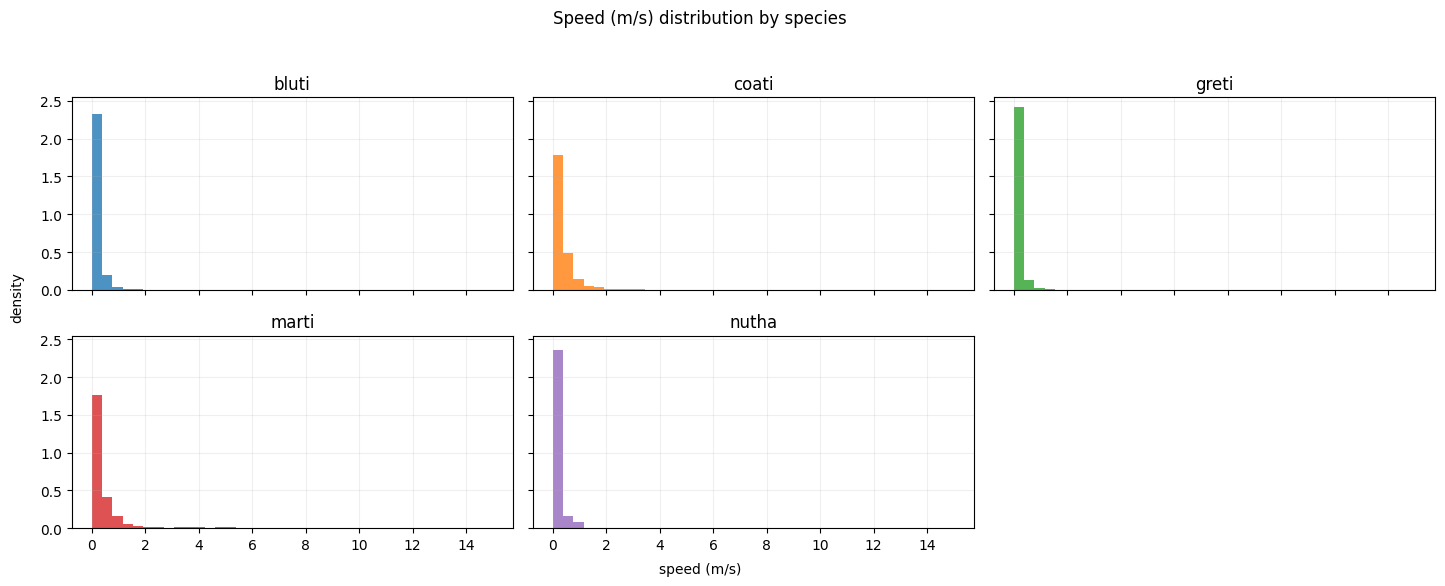

In [36]:
# Histograms of speeds per species
species_list = [sp for sp in species_order if (df_visit_no_zero['species'] == sp).any()]
n = len(species_list)
ncols = 3
nrows = int(np.ceil(n / ncols))

# Robust max for x-axis and bins
vmax = np.nanpercentile(df_visit_no_zero['speed_m_s'], 99.5)
xmax = float(min(max(5.0, vmax), 15.0))  # clamp between 5 and 15 m/s
bins = np.linspace(0, xmax, 40)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3), sharex=True, sharey=True)
axs = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for i, sp in enumerate(species_list):
    ax = axs[i]
    data = df_visit_no_zero.loc[df_visit_no_zero['species'] == sp, 'speed_m_s'].dropna().values
    if data.size == 0:
        ax.set_visible(False)
        continue
    ax.hist(data, bins=bins, density=True, color=species_color.get(sp, '#888888'),
            alpha=0.8, edgecolor='none')
    ax.set_title(sp)
    ax.grid(alpha=0.2)

# Hide any unused axes
for j in range(len(species_list), len(axs)):
    axs[j].set_visible(False)

fig.suptitle('Speed (m/s) distribution by species', y=0.98)
fig.text(0.5, 0.04, 'speed (m/s)', ha='center')
fig.text(0.04, 0.5, 'density', va='center', rotation='vertical')
plt.tight_layout(rect=(0.05, 0.05, 1, 0.95))

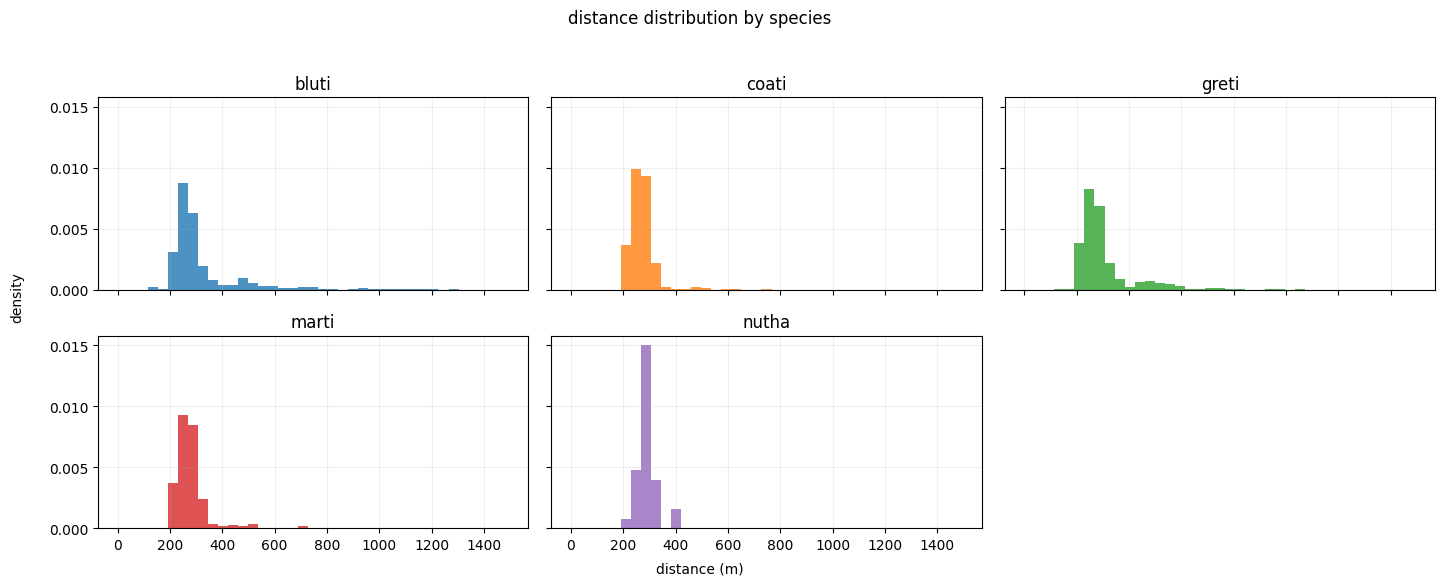

In [74]:
# Histograms of distances per species
species_list = [sp for sp in species_order if (df_visit_no_zero['species'] == sp).any()]
n = len(species_list)
ncols = 3
nrows = int(np.ceil(n / ncols))

# Robust max for x-axis and bins
dmax = np.nanpercentile(df_visit_no_zero['distance'], 99.5)
xmax = dmax
bins = np.linspace(0, xmax, 40)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3), sharex=True, sharey=True)
axs = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for i, sp in enumerate(species_list):
    ax = axs[i]
    data = df_visit_no_zero.loc[df_visit_no_zero['species'] == sp, 'distance'].dropna().values
    if data.size == 0:
        ax.set_visible(False)
        continue
    ax.hist(data, bins=bins, density=True, color=species_color.get(sp, '#888888'),
            alpha=0.8, edgecolor='none')
    ax.set_title(sp)
    ax.grid(alpha=0.2)

# Hide any unused axes
for j in range(len(species_list), len(axs)):
    axs[j].set_visible(False)

fig.suptitle('distance distribution by species', y=0.98)
fig.text(0.5, 0.04, 'distance (m)', ha='center')
fig.text(0.04, 0.5, 'density', va='center', rotation='vertical')
plt.tight_layout(rect=(0.05, 0.05, 1, 0.95))

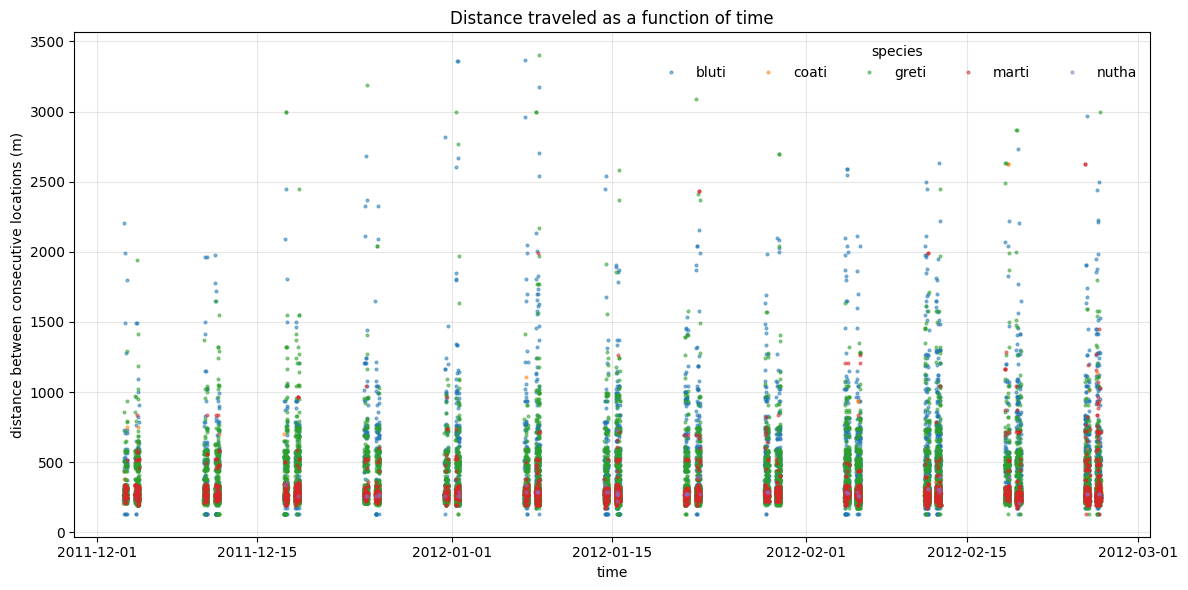

In [37]:
# Distance traveled as a function of time (per species)
fig, ax = plt.subplots(figsize=(12, 6))

for sp in species_order:
    sub_sp = df_visit[(df_visit['species'] == sp) & (df_visit['distance'] > 0)]
    if len(sub_sp) == 0:
        continue
    ax.plot(sub_sp['time_dt'], sub_sp['distance'], '.', ms=4, alpha=0.5,
            color=species_color.get(sp), label=sp)

ax.set_xlabel('time')
ax.set_ylabel('distance between consecutive locations (m)')
ax.set_title('Distance traveled as a function of time')
ax.grid(alpha=0.3)
ax.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

In [38]:
df_visit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63036 entries, 0 to 63035
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             63036 non-null  object        
 1   location       63036 non-null  object        
 2   species        63036 non-null  object        
 3   time_dt        63036 non-null  datetime64[ns]
 4   next_location  63036 non-null  object        
 5   next_time      63036 non-null  datetime64[ns]
 6   dt             63036 non-null  float64       
 7   distance       63036 non-null  float64       
 8   speed_m_s      63036 non-null  float64       
 9   same_day       63036 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(3), object(4)
memory usage: 4.4+ MB


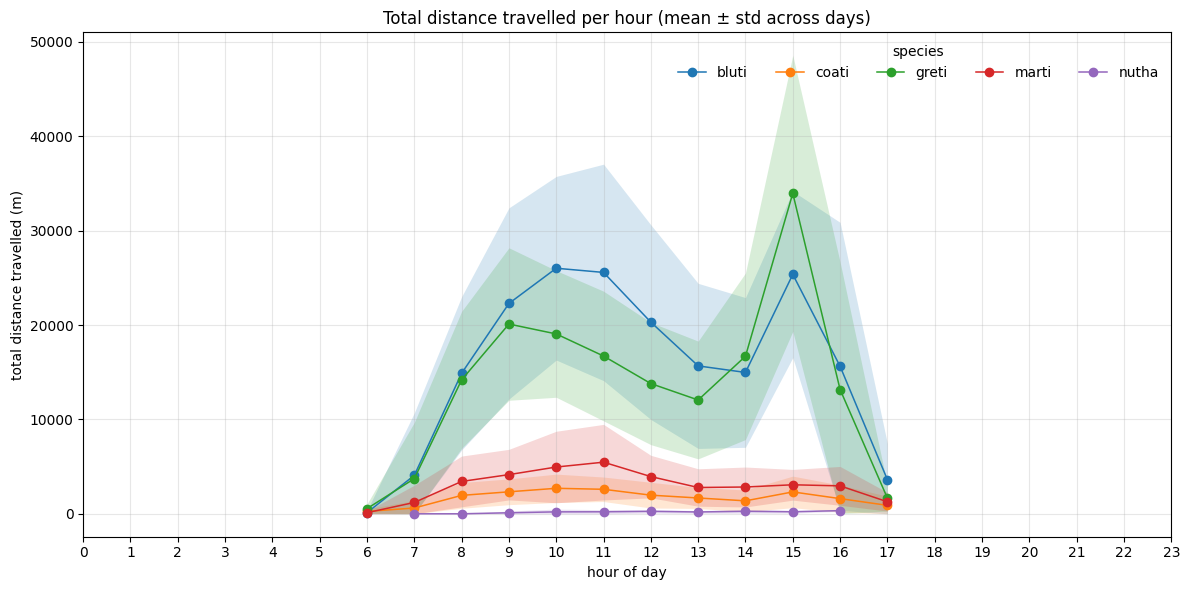

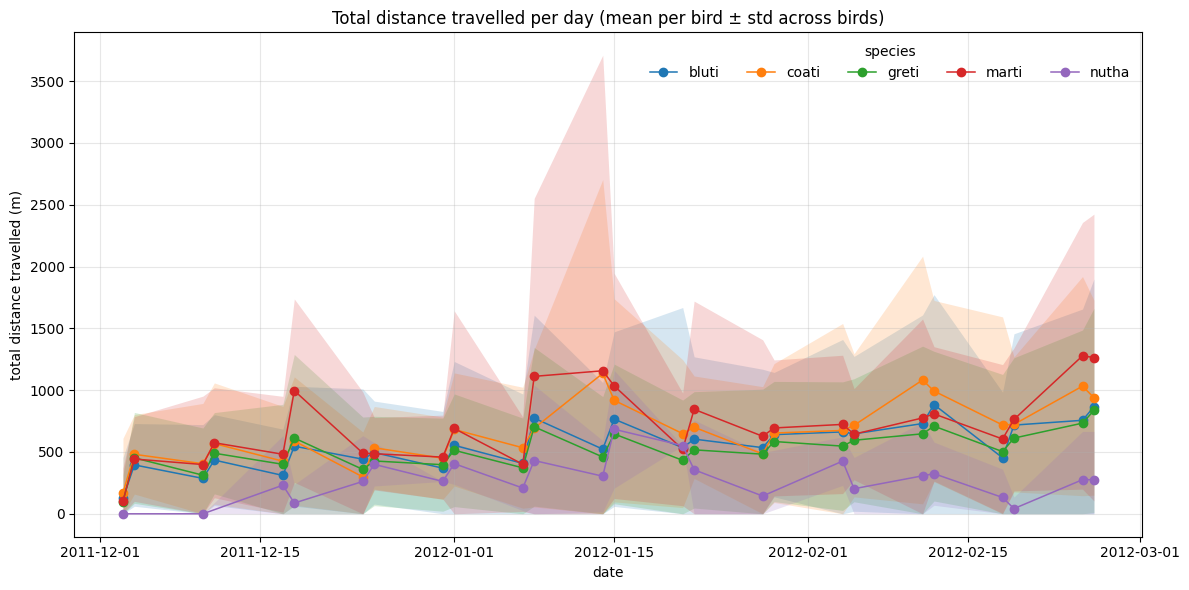

In [39]:
# Total distance travelled per hour and per day with ±1 std ribbons per species

# Use df_visit prepared above
sub = df_visit.dropna(subset=['time_dt', 'distance']).copy()
sub['day'] = sub['time_dt'].dt.floor('D')
sub['hour'] = sub['time_dt'].dt.hour

# 1) Total distance per hour (sum per day-hour, then mean ± std across days)
hourly_day = (
    sub.groupby(['species', 'day', 'hour'])['distance']
       .sum()
       .reset_index(name='total_distance')
)
hourly_stats = (
    hourly_day.groupby(['species', 'hour'])['total_distance']
              .agg(['mean', 'std'])
              .reset_index()
)

fig_h, ax_h = plt.subplots(figsize=(12, 6))
hours = np.arange(24)
for sp in species_order:
    sp_stats = (
        hourly_stats[hourly_stats['species'] == sp]
        .set_index('hour')
        .reindex(range(24))
    )
    if sp_stats['mean'].notna().any():
        ribbon(
            ax_h,
            hours,
            sp_stats['mean'],
            sp_stats['std'].fillna(0),
            label=sp,
            color=species_color.get(sp),
            floor_zero=True
        )
ax_h.set_xticks(hours)
ax_h.set_xlabel('hour of day')
ax_h.set_ylabel('total distance travelled (m)')
ax_h.set_title('Total distance travelled per hour (mean ± std across days)')
ax_h.grid(alpha=0.3)
ax_h.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

# 2) Total distance per day (sum per bird per day, then mean ± std across birds)
daily_individual = (
    sub.groupby(['species', 'day', 'id'])['distance']
       .sum()
       .reset_index(name='total_distance')
)
daily_stats = (
    daily_individual.groupby(['species', 'day'])['total_distance']
                   .agg(['mean', 'std'])
                   .reset_index()
)

fig_d, ax_d = plt.subplots(figsize=(12, 6))
for sp in species_order:
    sp_day = daily_stats[daily_stats['species'] == sp].sort_values('day')
    if not sp_day.empty:
        ribbon(
            ax_d,
            sp_day['day'].values,
            sp_day['mean'],
            sp_day['std'].fillna(0),
            label=sp,
            color=species_color.get(sp),
            floor_zero=True
        )
ax_d.set_xlabel('date')
ax_d.set_ylabel('total distance travelled (m)')
ax_d.set_title('Total distance travelled per day (mean per bird ± std across birds)')
ax_d.grid(alpha=0.3)
ax_d.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

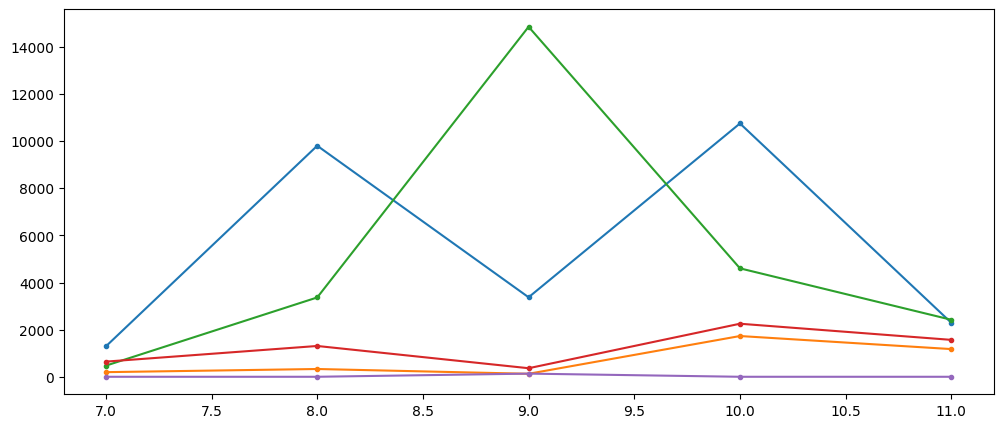

In [40]:
hour_spec = (
    df_visit.dropna(subset=['time_dt'])
    .assign(hour=df['time_dt'].dt.hour)
    .groupby(['hour', 'species']).size()
    .unstack(fill_value=0)
    .sort_index()
)
fig3, ax3 = plt.subplots(figsize=(12, 5))
for sp in hour_spec.columns:
    ax3.plot(hour_spec.index, hour_spec[sp], marker='o', ms=3,
             label=sp, color=species_color.get(sp, None))

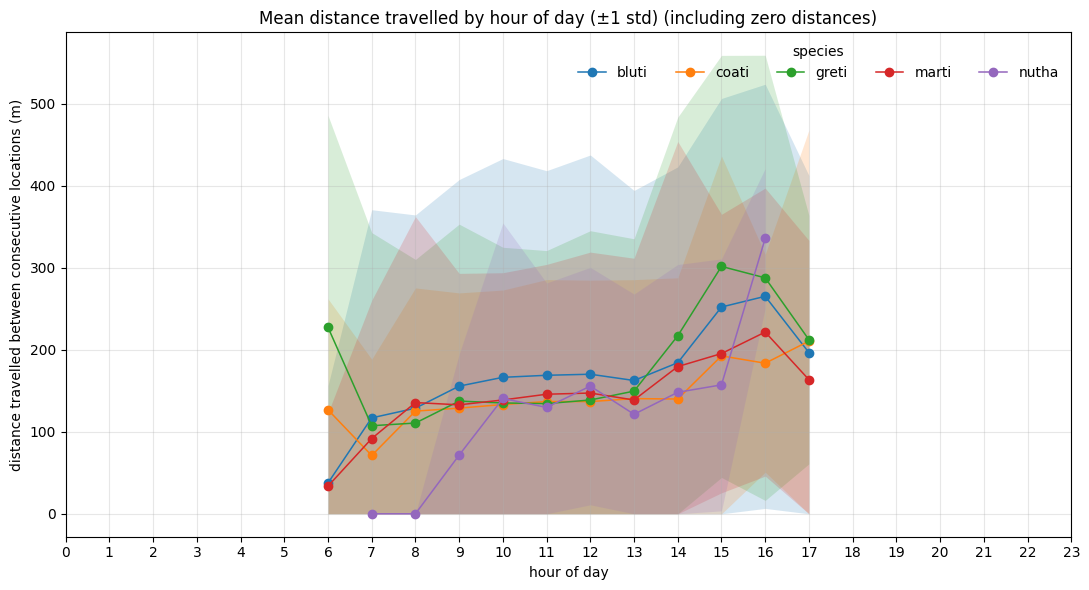

In [41]:
# plot mean and std of number of visits by hour of day
fig_hour_std, ax_visits = plt.subplots(figsize=(11,6))
hours = np.arange(0,24)

sub = df_visit.dropna(subset=['time_dt']).copy()
# sub = sub[sub['distance'] > 0]
sub['hour'] = sub['time_dt'].dt.hour

for sp in species_order:
    sp_hour = (
    sub.loc[sub['species'] == sp]
    .groupby('hour')['distance']
    .agg(['mean','std'])
    .reindex(range(24))
    )
    ribbon(ax_visits, hours, sp_hour['mean'], sp_hour['std'], label=sp, color=species_color.get(sp), floor_zero=True)
ax_visits.set_xticks(hours)
ax_visits.set_xlabel('hour of day')
ax_visits.set_ylabel('distance travelled between consecutive locations (m)')
ax_visits.set_title('Mean distance travelled by hour of day (±1 std) (including zero distances)')
ax_visits.grid(alpha=0.3)
ax_visits.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

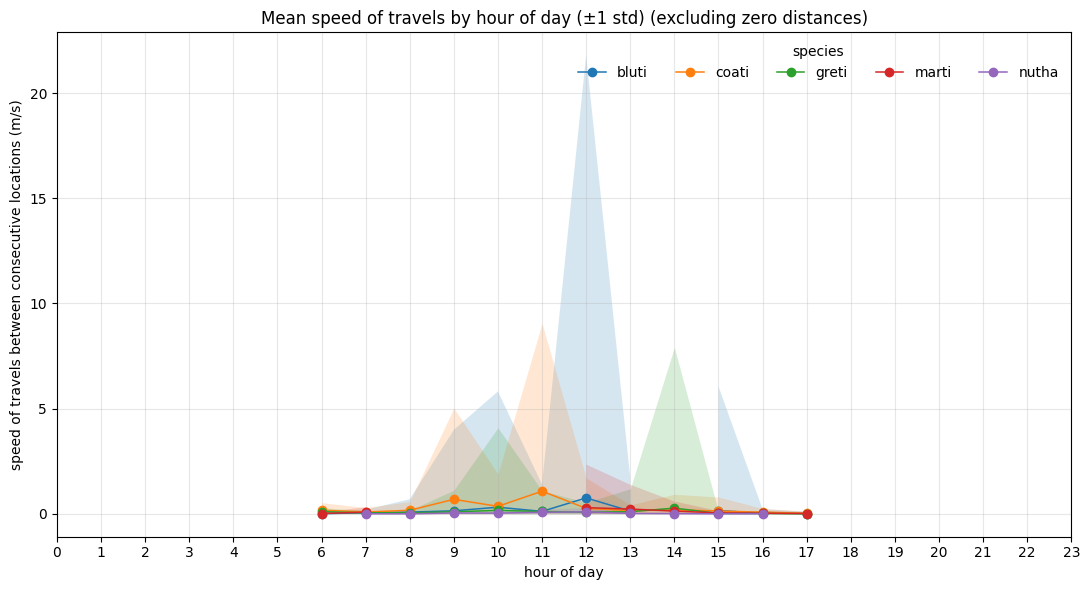

In [42]:
# plot mean and std of speed by hour of day
fig_hour_std, ax_visits = plt.subplots(figsize=(11,6))
hours = np.arange(0,24)

sub = df_visit.dropna(subset=['time_dt']).copy()
# sub = sub[sub['distance'] > 0]
sub['hour'] = sub['time_dt'].dt.hour

for sp in species_order:
    sp_hour = (
    sub.loc[sub['species'] == sp]
    .groupby('hour')['speed_m_s']
    .agg(['mean','std'])
    .reindex(range(24))
    )
    ribbon(ax_visits, hours, sp_hour['mean'], sp_hour['std'], label=sp, color=species_color.get(sp), floor_zero=True)
ax_visits.set_xticks(hours)
ax_visits.set_xlabel('hour of day')
ax_visits.set_ylabel('speed of travels between consecutive locations (m/s)')
ax_visits.set_title('Mean speed of travels by hour of day (±1 std) (excluding zero distances)')
ax_visits.grid(alpha=0.3)
ax_visits.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

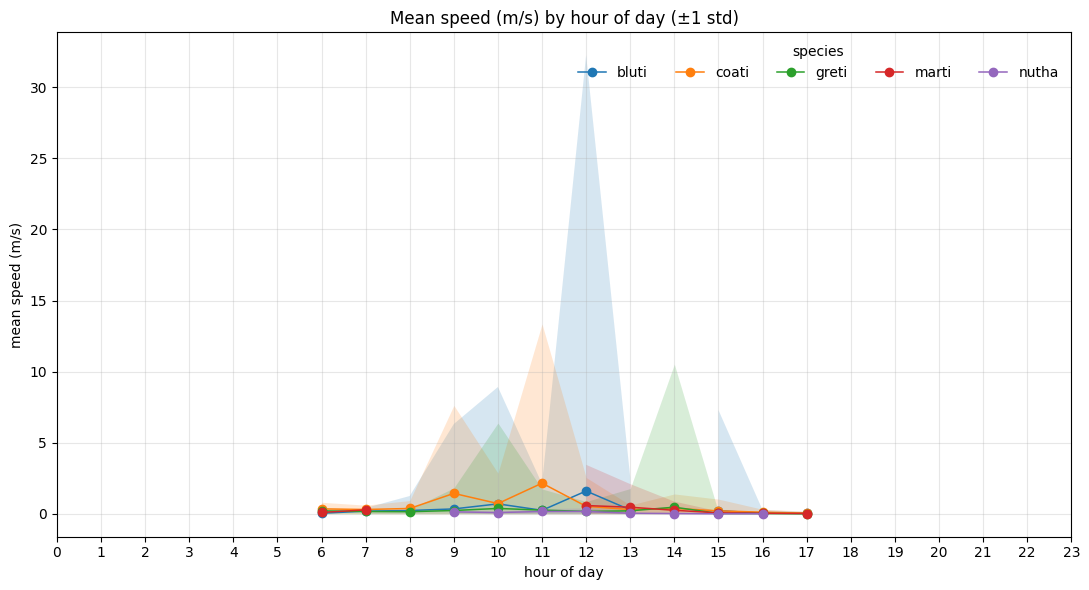

In [43]:
# Speed (m/s) mean ± std by hour of day

# pick data: prefer sub_sp if present, else use full df_visit
try:
    data = sub_sp.copy()
except NameError:
    data = df_visit.copy()
data = df_visit.copy()

# keep valid timestamps and positive speeds (exclude zero-distance hops)
data = data.dropna(subset=['time_dt', 'speed_m_s'])
if 'distance' in data.columns:
    data = data[data['distance'] > 0]
else:
    data = data[data['speed_m_s'] > 0]

data['hour'] = data['time_dt'].dt.hour

# species to plot (respect existing ordering/colors if available)
if 'species_order' in globals():
    species_list = [sp for sp in species_order if (data['species'] == sp).any()]
else:
    species_list = sorted(data['species'].dropna().unique())

fig, ax = plt.subplots(figsize=(11, 6))
hours = np.arange(24)

for sp in species_list:
    sp_stats = (
        data.loc[data['species'] == sp]
        .groupby('hour')['speed_m_s']
        .agg(['mean', 'std'])
        .reindex(range(24))
    )
    if sp_stats['mean'].notna().any():
        color = species_color.get(sp, None) if 'species_color' in globals() else None
        ribbon(ax, hours, sp_stats['mean'], sp_stats['std'],
               label=sp, color=color, floor_zero=True)

ax.set_xticks(hours)
ax.set_xlabel('hour of day')
ax.set_ylabel('mean speed (m/s)')
ax.set_title('Mean speed (m/s) by hour of day (±1 std)')
ax.grid(alpha=0.3)
ax.legend(title='species', ncol=min(len(species_list), 6), frameon=False, loc='upper right')
plt.tight_layout()

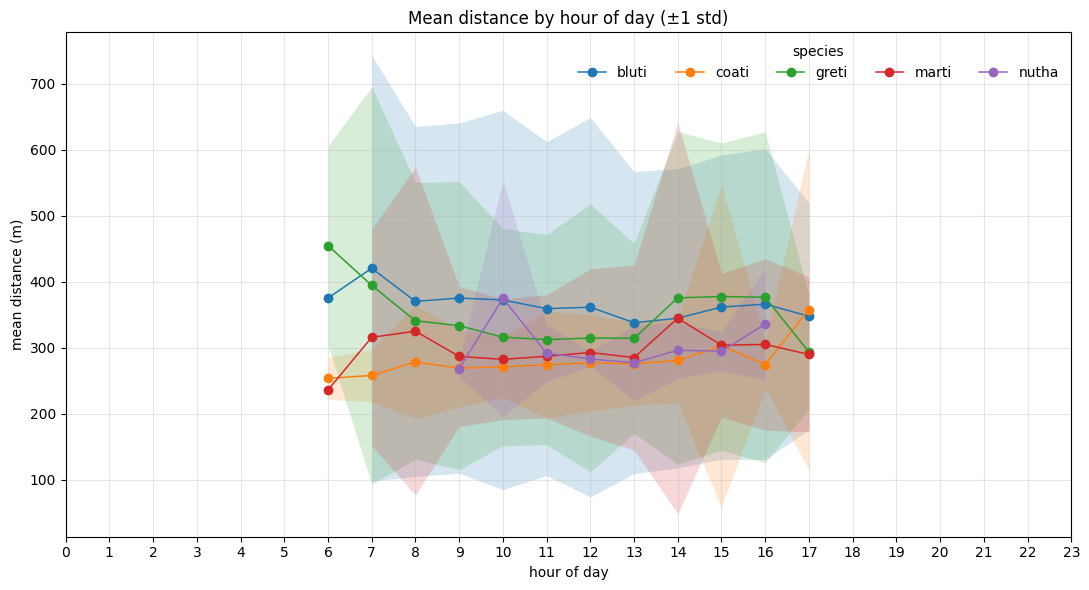

In [44]:
# distance (m) mean ± std by hour of day

# pick data: prefer sub_sp if present, else use full df_visit
try:
    data = sub_sp.copy()
except NameError:
    data = df_visit.copy()
data = df_visit.copy()

# keep valid timestamps and positive speeds (exclude zero-distance hops)
data = data.dropna(subset=['time_dt', 'distance'])
if 'distance' in data.columns:
    data = data[data['distance'] > 0]
else:
    data = data[data['speed_m_s'] > 0]

data['hour'] = data['time_dt'].dt.hour

# species to plot (respect existing ordering/colors if available)
if 'species_order' in globals():
    species_list = [sp for sp in species_order if (data['species'] == sp).any()]
else:
    species_list = sorted(data['species'].dropna().unique())

fig, ax = plt.subplots(figsize=(11, 6))
hours = np.arange(24)

for sp in species_list:
    sp_stats = (
        data.loc[data['species'] == sp]
        .groupby('hour')['distance']
        .agg(['mean', 'std'])
        .reindex(range(24))
    )
    if sp_stats['mean'].notna().any():
        color = species_color.get(sp, None) if 'species_color' in globals() else None
        ribbon(ax, hours, sp_stats['mean'], sp_stats['std'],
               label=sp, color=color, floor_zero=True)

ax.set_xticks(hours)
ax.set_xlabel('hour of day')
ax.set_ylabel('mean distance (m)')
ax.set_title('Mean distance by hour of day (±1 std)')
ax.grid(alpha=0.3)
ax.legend(title='species', ncol=min(len(species_list), 6), frameon=False, loc='upper right')
plt.tight_layout()

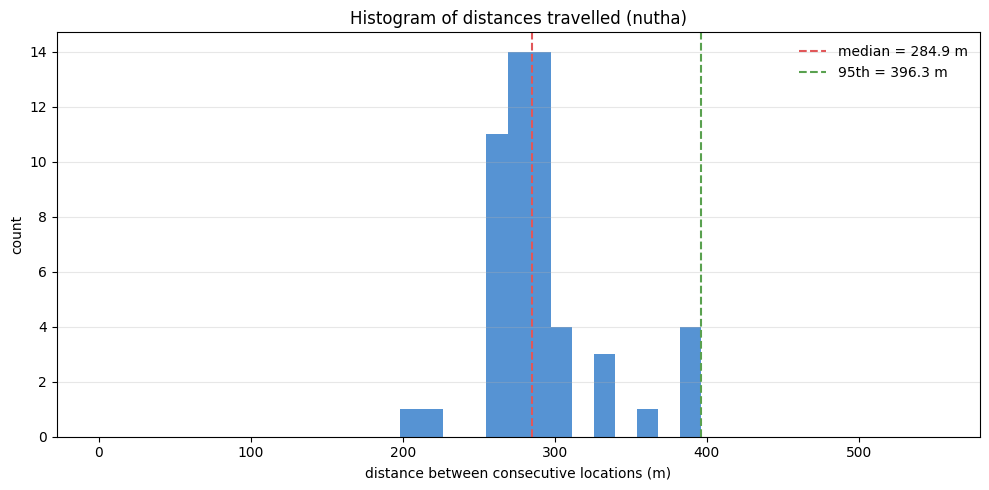

In [45]:
# Histogram of distances travelled (using sub_sp)
distances = sub_sp['distance'].dropna()
if distances.empty:
    print('No distance data to plot.')
else:
    # robust upper limit to avoid long tails dominating the plot
    d99 = float(np.nanpercentile(distances, 99))
    bins = np.linspace(0, d99, 40)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(distances, bins=bins, color="#2c78c9", alpha=0.8, edgecolor='none')
    med = float(np.nanmedian(distances))
    p95 = float(np.nanpercentile(distances, 95))
    ax.axvline(med, color='#e15759', linestyle='--', linewidth=1.5, label=f'median = {med:.1f} m')
    ax.axvline(p95, color='#59a14f', linestyle='--', linewidth=1.5, label=f'95th = {p95:.1f} m')

    sp_label = sub_sp['species'].iloc[0] if len(sub_sp) else ''
    ax.set_title(f'Histogram of distances travelled ({sp_label})')
    ax.set_xlabel('distance between consecutive locations (m)')
    ax.set_ylabel('count')
    ax.grid(alpha=0.3, axis='y')
    ax.legend(frameon=False)
    plt.tight_layout()

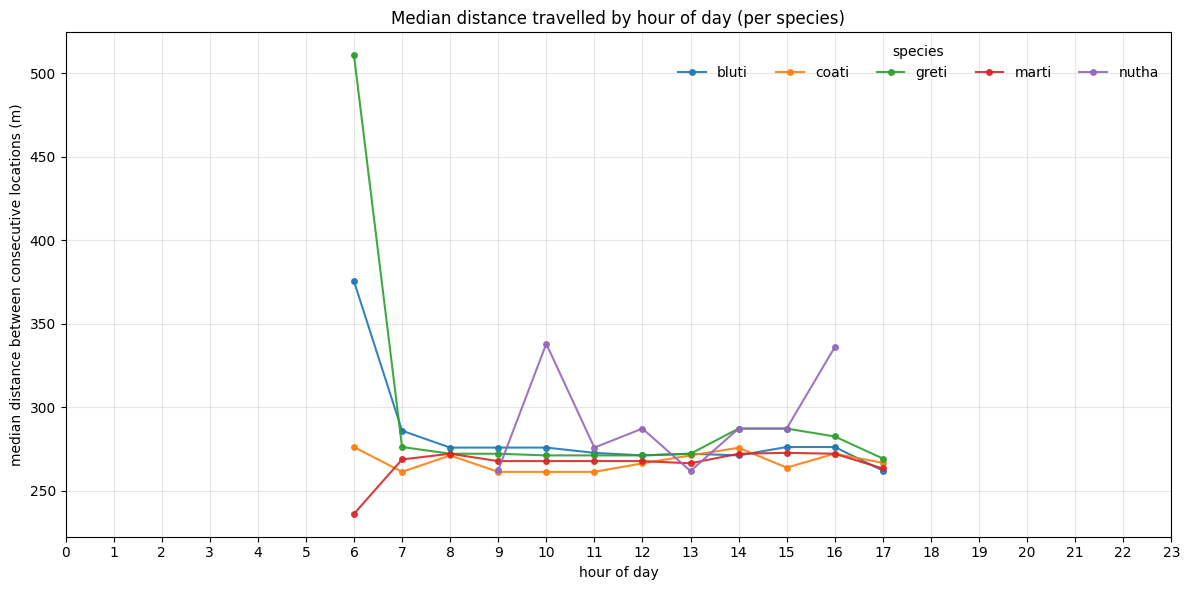

In [46]:
# Distance travelled as a function of hour of day (per species) - median per hour

sub = df_visit.dropna(subset=['time_dt']).copy()
sub = sub[sub['distance'] > 0]
sub['hour'] = sub['time_dt'].dt.hour

fig, ax = plt.subplots(figsize=(12, 6))
for sp in species_order:
    sp_hour = (
        sub.loc[sub['species'] == sp]
        .groupby('hour')['distance']
        .median()
        .reindex(range(24))
    )
    if sp_hour.notna().any():
        ax.plot(
            sp_hour.index, sp_hour.values, marker='o', ms=4,
            color=species_color.get(sp), label=sp, alpha=0.9
        )

ax.set_xlabel('hour of day')
ax.set_ylabel('median distance between consecutive locations (m)')
ax.set_title('Median distance travelled by hour of day (per species)')
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
ax.legend(title='species', ncol=min(len(species_order), 6), frameon=False, loc='upper right')
plt.tight_layout()

In [79]:
df_visit.head(10)

,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s,next_day,same_day
0,c695905,1c,bluti,2011-12-03 08:34:37,1c,2011-12-03 09:04:50,1813.0,0.000000,0.000000,2011-12-03,True
1,c695905,1c,bluti,2011-12-03 09:04:50,1d,2011-12-03 09:48:51,2641.0,275.870519,0.104457,2011-12-03,True
2,c695905,1d,bluti,2011-12-03 09:48:51,1d,2011-12-04 10:57:23,90512.0,0.000000,0.000000,2011-12-04,False
3,c695905,1d,bluti,2011-12-04 10:57:23,1c,2011-12-04 11:22:51,1528.0,275.870519,0.180544,2011-12-04,True
4,c695905,1c,bluti,2011-12-04 11:22:51,1c,2011-12-10 11:00:26,517055.0,0.000000,0.000000,2011-12-10,False
5,c695905,1c,bluti,2011-12-10 11:00:26,1d,2011-12-10 11:15:12,886.0,275.870519,0.311366,2011-12-10,True
6,c695905,1d,bluti,2011-12-10 11:15:12,1d,2011-12-11 10:57:17,85325.0,0.000000,0.000000,2011-12-11,False
7,c695905,1d,bluti,2011-12-11 10:57:17,1c,2011-12-11 11:24:15,1618.0,275.870519,0.170501,2011-12-11,True
8,c695905,1c,bluti,2011-12-11 11:24:15,1c,2011-12-11 15:39:59,15344.0,0.000000,0.000000,2011-12-11,True
9,c695905,1c,bluti,2011-12-11 15:39:59,1d,2011-12-17 09:13:08,495189.0,275.870519,0.000000,2011-12-17,False


# sorting out weird speeds and locations

In [92]:
# max speed should be around 20km/h as max physically is roughly 50km/h and they wont go in a straight lineas fast as possible one location to next
print(f'50km/h in m/s is {50*1000/3600}')

50km/h in m/s is 13.88888888888889


In [93]:
max_speed_species = df_visit.groupby('species')['speed_m_s'].max().sort_values(ascending=False)
print(max_speed_species.head())

species
bluti           inf
marti           inf
greti    337.501471
coati    125.463446
nutha      0.907469
Name: speed_m_s, dtype: float64


In [50]:
max_speed_new_loc = df_new_loc.groupby('species')['speed_m_s'].max().sort_values(ascending=False)
print(max_speed_new_loc.head())

species
bluti           inf
marti           inf
greti    337.501471
coati    125.463446
nutha      0.907469
Name: speed_m_s, dtype: float64


In [60]:
# max speed attained by each bird
max_speeds = df_visit.groupby('id')['speed_m_s'].max().sort_values(ascending=False)
print(max_speeds.head(20)) 

id
y031266           inf
y161058           inf
l171445           inf
y035978           inf
l314221           inf
l312199           inf
l314579    948.207062
ts46407    337.501471
y031516    301.849507
x237533    294.051441
x662382    234.317016
r639342    232.206804
y033150    125.463446
y035884     94.762558
n199823     77.576172
y146735     77.402268
l326744     77.402268
tl36119     58.051701
y160411     58.051701
y160415     33.172401
Name: speed_m_s, dtype: float64


High-speed records: 122 rows; total location counts (location + next_location) = 244


,location,high_speed_count
0,1A,0
1,1B,6
2,1C,0
3,1D,0
4,1E,1


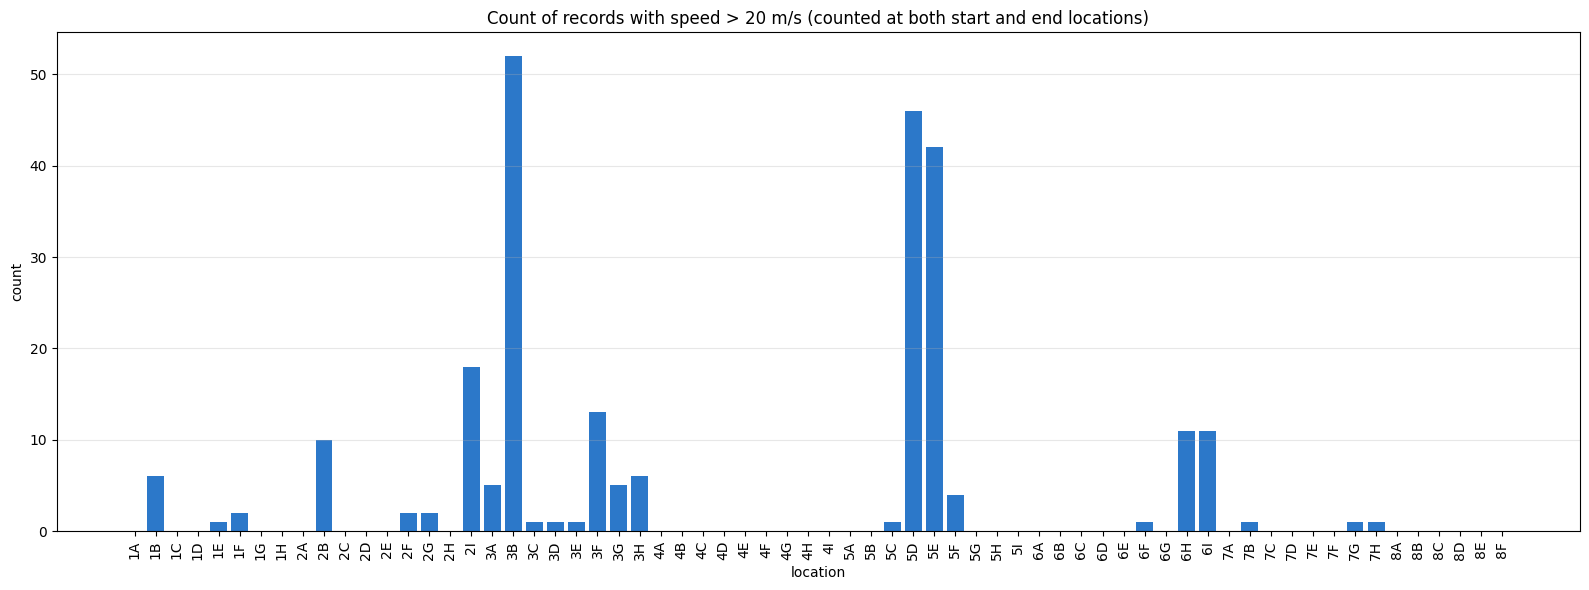

In [ ]:
# Count high-speed (>20 m/s) records per location (counting both location and next_location) and plot

# filter high-speed rows
fast_records = df_visit.loc[df_visit['speed_m_s'] > 20, ['location', 'next_location']].copy()

# stack both columns into a single list of locations, normalize casing, drop missing
loc_series = pd.concat([fast_records['location'], fast_records['next_location']], ignore_index=True)
loc_series = loc_series.dropna().astype(str).str.strip().str.upper()

# order by known locations from df_locations (normalize to upper for alignment)
known_locs = df_locations['Name'].astype(str).str.upper().tolist()
highspeed_counts = loc_series.value_counts().reindex(known_locs, fill_value=0)

# as a DataFrame (optional to inspect)
highspeed_counts_df = highspeed_counts.reset_index()
highspeed_counts_df.columns = ['location', 'high_speed_count']

# plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(highspeed_counts_df['location'], highspeed_counts_df['high_speed_count'],
    color="#2c78c9", edgecolor='none')
ax.set_title('Count of records with speed > 20 m/s (counted at both start and end locations)')
ax.set_xlabel('location')
ax.set_ylabel('count')
ax.grid(alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()

# print a short summary
total_fast_records = (df_visit['speed_m_s'] > 20).sum()
print(f'High-speed records: {total_fast_records} rows; total location counts (location + next_location) = {int(highspeed_counts.sum())}')
highspeed_counts_df.head()

Removing locations with more than 20 high-speed records: ['2I', '3B', '3F', '5D', '5E', '6H', '6I']
Removed 8402 records; remaining 54634 records.


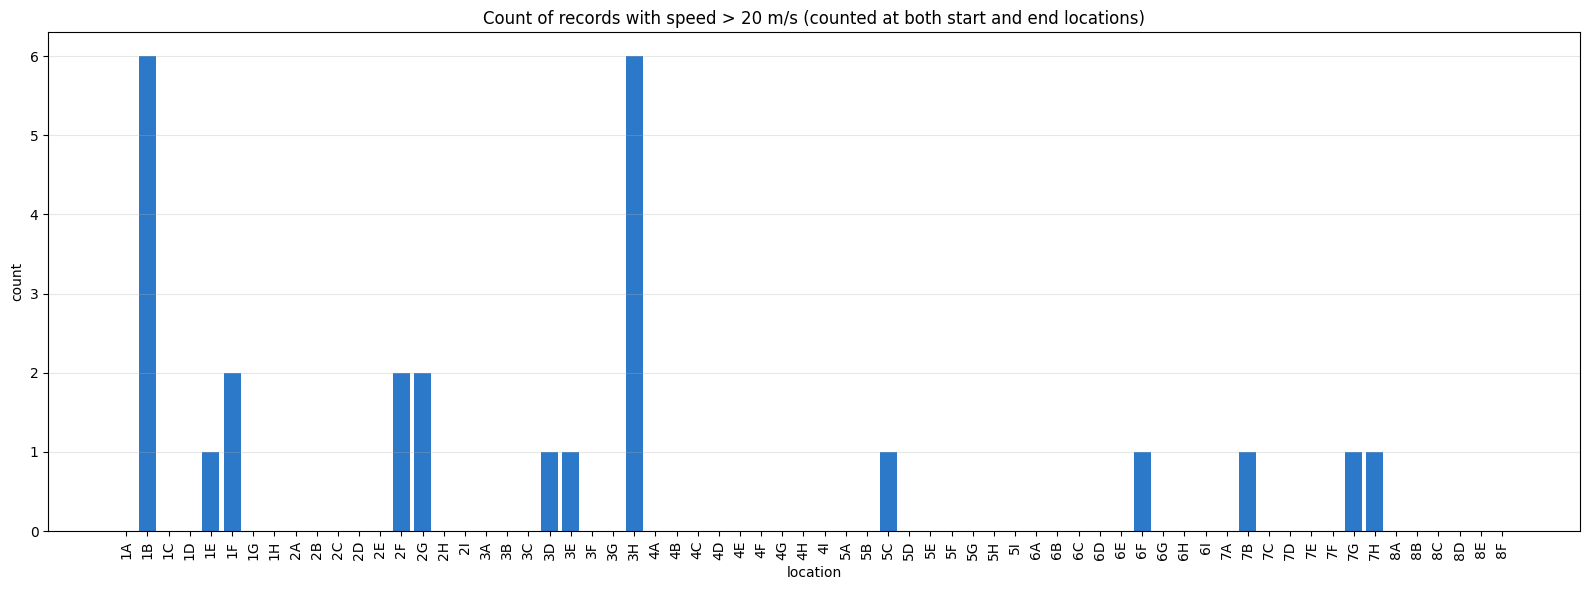

In [59]:
# remove records where the location or next_location is contains more than 20 counts of high-speed records
locations_to_remove = highspeed_counts[highspeed_counts > 10].index.tolist()
print(f'Removing locations with more than 20 high-speed records: {locations_to_remove}')
df_fast_filtered = df_visit[
    ~df_visit['location'].str.upper().isin(locations_to_remove) &
    ~df_visit['next_location'].str.upper().isin(locations_to_remove)
].copy()
print(f'Removed {len(df_visit) - len(df_fast_filtered)} records; remaining {len(df_fast_filtered)} records.')

# filter high-speed rows
fast_records = df_fast_filtered.loc[df_fast_filtered['speed_m_s'] > 20, ['location', 'next_location']].copy()

# stack both columns into a single list of locations, normalize casing, drop missing
loc_series = pd.concat([fast_records['location'], fast_records['next_location']], ignore_index=True)
loc_series = loc_series.dropna().astype(str).str.strip().str.upper()

# order by known locations from df_locations (normalize to upper for alignment)
known_locs = df_locations['Name'].astype(str).str.upper().tolist()
highspeed_counts = loc_series.value_counts().reindex(known_locs, fill_value=0)

# as a DataFrame (optional to inspect)
highspeed_counts_df = highspeed_counts.reset_index()
highspeed_counts_df.columns = ['location', 'high_speed_count']

# plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(highspeed_counts_df['location'], highspeed_counts_df['high_speed_count'],
    color="#2c78c9", edgecolor='none')
ax.set_title('Count of records with speed > 20 m/s (counted at both start and end locations)')
ax.set_xlabel('location')
ax.set_ylabel('count')
ax.grid(alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()

In [53]:
df_fast = df_visit.copy()
df_fast['faster_than_20'] = df_fast['speed_m_s'] > 20
df_fast['keep'] = (df_fast['faster_than_20']==True) | (df_fast['faster_than_20'].shift(1, fill_value=False) | df_fast['faster_than_20'].shift(-1, fill_value=False))
df_fast_check = df_fast[df_fast['keep']].copy()
print(f"Number of rows with speed > 20 m/s or adjacent to such rows: {len(df_fast_check)}")
df_fast_check.head(20)

Number of rows with speed > 20 m/s or adjacent to such rows: 279


,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s,same_day,faster_than_20,keep
1884,l171445,2i,marti,2012-01-01 08:56:35,2i,2012-01-01 08:57:35,60.0,0.000000,0.000000,True,False,True
1885,l171445,2i,marti,2012-01-01 08:57:35,3b,2012-01-01 08:57:48,13.0,283.778082,21.829083,True,True,True
1886,l171445,3b,marti,2012-01-01 08:57:48,3b,2012-01-01 09:00:59,191.0,0.000000,0.000000,True,False,True
1892,l171445,2i,marti,2012-01-01 09:09:02,2i,2012-01-01 09:09:05,3.0,0.000000,0.000000,True,False,True
1893,l171445,2i,marti,2012-01-01 09:09:05,3b,2012-01-01 09:09:06,1.0,283.778082,283.778082,True,True,True
1894,l171445,3b,marti,2012-01-01 09:09:06,2i,2012-01-01 09:09:07,1.0,283.778082,283.778082,True,True,True
1895,l171445,2i,marti,2012-01-01 09:09:07,3b,2012-01-01 09:09:07,0.0,283.778082,inf,True,True,True
1896,l171445,3b,marti,2012-01-01 09:09:07,2i,2012-01-01 09:09:09,2.0,283.778082,141.889041,True,True,True
1897,l171445,2i,marti,2012-01-01 09:09:09,2i,2012-01-01 09:09:24,15.0,0.000000,0.000000,True,False,True
1918,l171445,3b,marti,2012-01-08 10:45:13,3b,2012-01-08 10:45:17,4.0,0.000000,0.000000,True,False,True


In [52]:
from IPython.display import display

# Show records with speeds above 20 (both m/s and km/h thresholds)


cols = ['id', 'species', 'location', 'next_location', 'time_dt', 'next_time', 'distance', 'dt', 'speed_m_s']

# > 20 m/s
fast_gt20_ms = (
    df_visit.loc[df_visit['speed_m_s'] > 20, cols]
    .sort_values('speed_m_s', ascending=False)
    .reset_index(drop=True)
)
print(f'> 20 m/s: {len(fast_gt20_ms)} rows')
display(fast_gt20_ms)


> 20 m/s: 122 rows


,id,species,location,next_location,time_dt,next_time,distance,dt,speed_m_s
0,y035978,marti,5d,5e,2012-01-14 09:38:32,2012-01-14 09:38:32,250.926892,0.0,inf
1,l314221,marti,6h,6i,2012-02-25 11:14:02,2012-02-25 11:14:02,220.911747,0.0,inf
2,l314221,marti,6h,6i,2012-02-25 11:14:01,2012-02-25 11:14:01,220.911747,0.0,inf
3,l312199,marti,3a,3b,2012-01-15 11:21:19,2012-01-15 11:21:19,336.810035,0.0,inf
4,y161058,marti,5d,5e,2012-01-14 11:30:07,2012-01-14 11:30:07,250.926892,0.0,inf
...,...,...,...,...,...,...,...,...,...
117,l312199,marti,3b,2i,2012-01-14 09:10:10,2012-01-14 09:10:23,283.778082,13.0,21.829083
118,l171445,marti,2i,3b,2012-01-01 08:57:35,2012-01-01 08:57:48,283.778082,13.0,21.829083
119,r639342,greti,3f,3b,2012-01-28 10:55:22,2012-01-28 10:55:33,232.206804,11.0,21.109709
120,y035978,marti,5e,5d,2012-01-14 09:34:38,2012-01-14 09:34:50,250.926892,12.0,20.910574
